# IGNITE: Inference of Gene Regulatory Network using Kinetic Ising Model


In [1]:
from datetime import date 
# Prints the last run date of the script for tracking purposes
print("Last run date:", date.today())

Last run date: 2025-08-29


In [2]:
# Import standard libraries
import os  
import time
from tqdm import tqdm
import warnings
import random

# Import third-party libraries
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from matplotlib.font_manager import FontProperties
import matplotlib.colors as pltcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import MultiPolygon
import matplotlib.ticker as ticker 
from shapely.geometry import Point
from joblib import Parallel, delayed

import seaborn as sns

import scipy
from scipy import stats
from scipy.stats import binom
import scipy.cluster.hierarchy as sch

import scanpy as sc

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from scipy.stats import shapiro, kstest
from scipy.stats import zscore

# Import custom modules for specific functionalities
import lib.figs_funcs as figs_funcs
import lib.funcs_general as funcs_general
import lib.funcs_grn_search_old as funcs_grn_search
import lib.funcs_ko as funcs_ko
import lib.NetAnalysis as na
import lib.funcs_pca as pca_funcs
import lib.funcs_cl_out as cl_funcs

# Setting up matplotlib to use LaTeX for text rendering
matplotlib.rc('text', usetex=True)

# Setting up seaborn for aesthetics
sns.set(font='Avenir')
sns.set(style="white")

# Enabling autoreload extension for automatically reloading modules
%load_ext autoreload
%autoreload 2


# Loading Info and Data

## Information

In [3]:
# Defining paths for code and data directories
path      = os.getcwd() # "/GRN_Inference/GRN_Inference_CODE/" 
path_gen  = os.path.dirname(os.path.dirname(path)) # "/GRN_Inference/


In [4]:
path_human_fig  = "/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/"

In [5]:
# Timepoints for the dataset
time_steps = ["00h", "12h", "24h", "36h", "72h", "96h"]

# read tf_hvg_genes.txt
genes_relevant = np.loadtxt(path + "/input_data/tf_hvg_genes_wilcox.txt", dtype=str)
print(f"number of genes: {len(genes_relevant)} & number of unique genes: {len(np.unique(genes_relevant))}")


number of genes: 100 & number of unique genes: 100


In [6]:
# remove genes that are importan only for SCODE
genes_scode_remove = ["SNAI1", "SATB1"] #["GATA3", "GRHL2", "LEF1", "SNAI1", "SATB1", "ZFP42"] # 
genes_relevant = np.setdiff1d(genes_relevant, genes_scode_remove)
genes_relevant.shape

(98,)

In [7]:
# # check the presence of the manually added genes: "CXCR4", "KLF8", "HNF4A", "GLIS1"
# print("Checking the presence of the manually added genes: 'CXCR4', 'KLF8', 'HNF4A', 'GLIS1'")
# if "CXCR4" in genes_relevant and "KLF8" in genes_relevant and "HNF4A" in genes_relevant and "GLIS1" in genes_relevant:
#     print("Added genes are present")

    

#### Genes for paper comparison

In [8]:
# List of gene names from Western blot
genes_western_blot = ["CYCG", "HNF4A", "AFP", "ALB", "HNF1A", "APOA1", "APOA2", "APOB", "APOC2", "APOC3"]

# Updated list of gene names from the right of the heatmap
genes_heatmap = [
    "APOA2", "AHSG", "FGG", "VTN", "FGA", "HPX", "UGT2B28", "ORM1", "PLG",
    "APOC2", "APOH", "SERPIND1", "ANG", "ITIH1", "F2", "TDO2", "C5", "KNG1",
    "AMBP", "SERPINC1", "ITIH2", "PON1", "HP", "MAT1A", "C2", "HPR", "SAA4",
    "HABP2", "C8B", "ATF5", "C6", "ITIH4", "CFHR2", "CPB2", "ITIH3", "CYP2E1",
    "CRP", "AGXT", "APCS", "CYP3A4"
]

# Combine lists and remove duplicates
all_genes_from_paper_2 = np.array([
    "NANOG", "SOX2", "CDX2", "HAND1", "GATA3", "TFAP2A", "KRT7", 
    "DLX3", "DLX5", "MSX1", "GATA4", "GATA6", "SOX7", "PAX6", "PLZF", 
    "ZIC1", "T", "MIXL1", "EOMES", "SOX17", "BMP4", "ID1", "ID2", "SMAD6"
])

print(len(all_genes_from_paper_2))
# check the present (common ones) genes in all_genes_from_paper_2 and spins_df_lN_mb_pst.index
genes_present_paper_2 = np.intersect1d(all_genes_from_paper_2, genes_relevant)
print("Genes in common between GRN and the paper", len(genes_present_paper_2))


24
Genes in common between GRN and the paper 15


## Data: LogNorm scRNA-seq SmartSeq

In [9]:
# load lognorm data ordered by PST
df_lN_all = pd.read_csv(path + "/input_data/tfs_logcounts_ordered_wilcox.csv", header=0, index_col=0, sep=",")

# select just the Relevant genes (rows with index contained in genes_relevant)
df_lN = df_lN_all.loc[genes_relevant].reindex(genes_relevant)
print("shape of the lognorm ge for selected genes:", df_lN.shape)

df_lN.head()


shape of the lognorm ge for selected genes: (98, 758)


,00hb4s_061,00hb4s_024,00hb4s_088,00hb4s_071,00hb4s_001,00hb4s_013,00hb4s_073,00hb4s_078,00hb4s_005,00hb4s_037,...,96h_010,96h_011,96h_012,96h_015,96h_020,96h_051,96h_052,96h_056,96h_058,96h_074
AEBP2,11.794883,12.268603,11.197917,11.414025,11.033223,11.597042,11.746212,11.245178,10.736419,11.332182,...,6.554589,6.712871,1.584963,4.451541,4.321928,2.592158,4.165912,9.285495,8.720689,9.552784
AFF3,4.980482,3.326250,4.909773,3.713696,4.386811,4.222650,3.200065,4.223423,3.854993,4.809929,...,3.705978,3.844988,3.735522,4.999549,2.456806,3.584963,2.384050,3.200065,3.536053,2.954196
ARGFX,6.148324,5.244887,5.537607,4.877744,5.730640,5.687901,4.444932,5.255501,6.013462,6.168522,...,3.778209,4.992768,4.625855,5.266787,4.372256,4.215679,4.451541,3.543496,5.598425,3.716991
ARID3A,0.000000,2.321928,1.000000,0.000000,1.000000,4.700440,0.000000,0.992768,0.000000,1.584963,...,7.577429,7.491853,5.584963,7.145677,4.754888,7.312883,4.857981,6.372604,4.523562,4.984589
BMP2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,7.022368,6.971888,1.000000,8.159165,2.000000,2.807355,3.700440,6.228819,7.417853


In [10]:
# Checking that the order of genes_relervant is the same as the order of the rows in df_lN
if np.all(genes_relevant == df_lN.index):
    print("The order of genes_relervant is the same as the order of the rows in df_lN")
df_lN.shape

The order of genes_relervant is the same as the order of the rows in df_lN


(98, 758)

In [11]:
# Calculate the fraction of zero values per gene
# zeros_perGene_frac = np.sum(df_lN == 0, axis=1) / df_lN.shape[1]

# plt.figure(figsize=(3, 12))
# s = sns.barplot(x=zeros_perGene_frac, y=df_lN.index, color='salmon')

# s.set_xlabel('Fraction of zeros', fontsize=8)
# s.set_ylabel('', fontsize=8)
# s.set_xticks([])
# s.set_xlim(0, 1.2)
# plt.yticks(fontsize=7)
# for i in range(len(df_lN.index)):
#     plt.text(x=zeros_perGene_frac[i]+0.01, y=i+0.3, s=(str(round(zeros_perGene_frac[i], 2))), size=8)
# plt.show()


/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


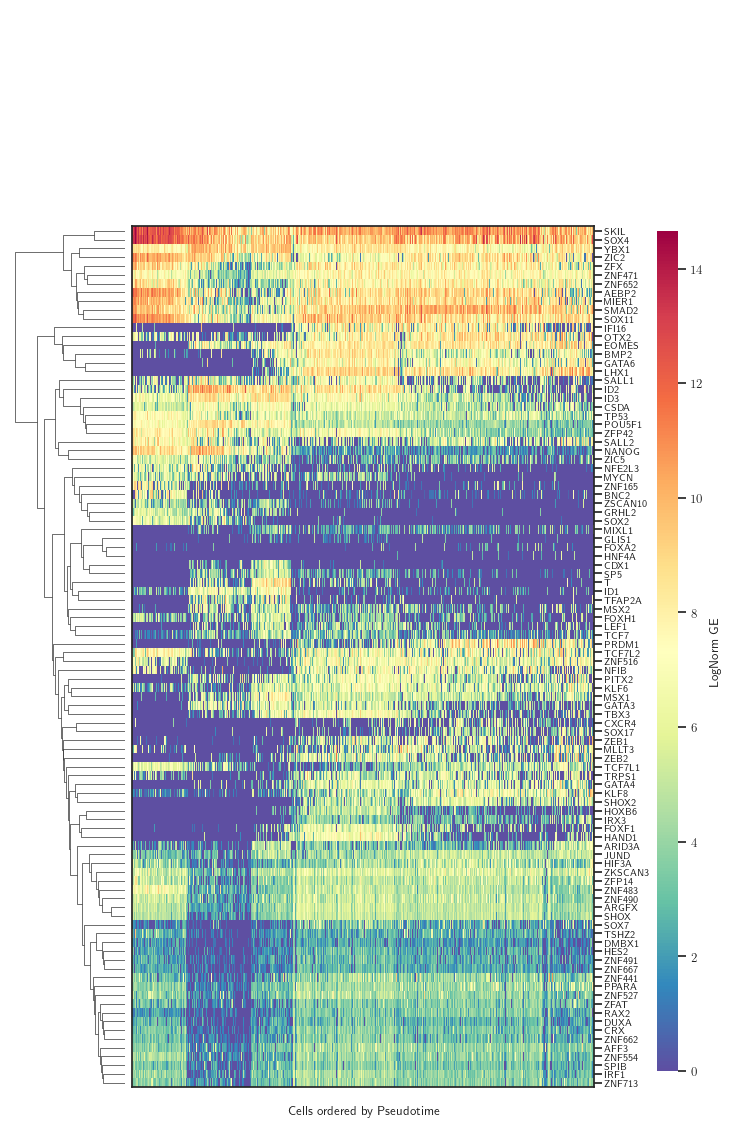

In [12]:
vmin = df_lN.min().min()
vmax = max(abs(df_lN).max())
cmap = 'Spectral_r'
g = sns.clustermap(df_lN, cmap=cmap, 
                   vmin=vmin, vmax=vmax, 
                   row_cluster=True, 
                   col_cluster=False, 
                   yticklabels=genes_relevant, 
                   figsize=(7, 12), 
                   cbar_kws={"label": "LogNorm GE"},
                   cbar_pos=(0.95, 0.1, 0.03, 0.7))  

g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_xlabel("Cells ordered by Pseudotime", fontsize=9)
g.ax_heatmap.tick_params(axis='y', pad=1, labelsize=7)

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)

# Personalizzare il olorbar
cbar = g.ax_heatmap.collections[0].colorbar
cbar.ax.yaxis.label.set_fontsize(9)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_visible(False)

### Mini-Bulk

In [13]:
# Window size for Mini-Bulk
mb_wind = 50

# Threshold for half max
thr = 0.5 

# MB
df_lN_mb_pst = pd.DataFrame(df_lN.rolling(window=mb_wind, axis=1).mean().dropna(axis=1), index=df_lN.index)
print("shape of the lognorm ge for selected genes (MB):", df_lN_mb_pst.shape)
df_lN_mb_pst.head(3)



shape of the lognorm ge for selected genes (MB): (98, 709)


,00hb4s_050,00hb4s_008,00hb4s_018,00hb4s_095,00hb4s_092,00hb4s_041,00hb4s_029,00hb4s_086,00hb4s_038,00hb4s_052,...,96h_010,96h_011,96h_012,96h_015,96h_020,96h_051,96h_052,96h_056,96h_058,96h_074
AEBP2,10.809621,10.783720,10.757155,10.738929,10.699135,10.700432,10.679402,10.643688,10.614313,10.567171,...,5.933581,5.853067,5.706742,5.612730,5.515425,5.479134,5.351971,5.537681,5.565477,5.590962
AFF3,3.942816,3.937711,3.945150,3.909242,3.914477,3.912567,3.912115,3.907714,3.873211,3.852504,...,3.624623,3.623656,3.629680,3.645545,3.639927,3.612136,3.605942,3.603533,3.636975,3.621676
ARGFX,5.071165,5.054924,5.052711,5.044062,5.052576,5.044603,5.043133,5.031711,5.024671,5.012255,...,4.198893,4.194295,4.194601,4.221265,4.239183,4.248334,4.250811,4.264922,4.304857,4.289617


/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


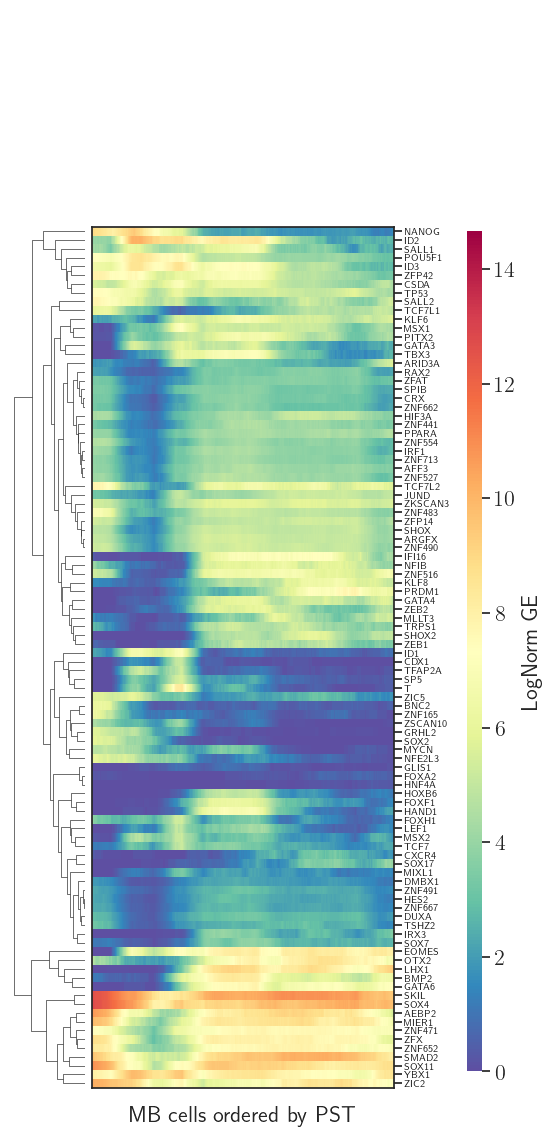

In [14]:
g = sns.clustermap(df_lN_mb_pst, cmap=cmap, 
                   vmin=vmin, vmax=vmax, 
                   row_cluster=True, col_cluster=False, 
                   yticklabels=genes_relevant, 
                   figsize=(5, 12), 
                   cbar_kws={"label": "LogNorm GE"},
                   cbar_pos=(0.95, 0.1, 0.03, 0.7))  # Posizionamento del colorbar

g.ax_heatmap.set_xticklabels([])
g.ax_heatmap.set_xlabel("MB cells ordered by PST", fontsize=16)
g.ax_heatmap.tick_params(axis='y', pad=1, labelsize=7)

for spine in g.ax_heatmap.spines.values():
    spine.set_visible(True)

# Personalizzare il olorbar
cbar = g.ax_heatmap.collections[0].colorbar
cbar.ax.yaxis.label.set_fontsize(16)
cbar.ax.tick_params(labelsize=16)
cbar.outline.set_visible(False)

# Save as tiff in the path '/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human'
g.fig.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS7/E_human_heatmap_mb_pst.tiff", 
              dpi=300, 
              bbox_inches='tight')

row_order = g.dendrogram_row.reordered_ind
genes_reordered_clust = [genes_relevant[i] for i in row_order]


### PST

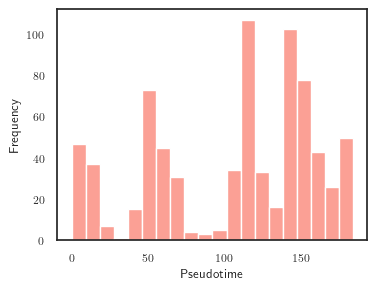

In [15]:
# load from input_data folder the pst values per each cell: pseudotime_hPSCs_ordered.txt
pseudotime_vals = np.loadtxt(path + "/input_data/pseudotime_hPSCs_ordered_wilcox.txt", dtype=float)

# plot the distribution of the pseudotime values
plt.figure(figsize=(4, 3))
sns.histplot(pseudotime_vals, bins=20, color='salmon')
plt.xlabel('Pseudotime', fontsize=9)
plt.ylabel('Frequency', fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()



In [16]:
pseudotime_vals.max()


183.583624518319

In [17]:
# averaging the pseudotime array
pst_mb_avg = np.array(pd.DataFrame(pseudotime_vals).rolling(window=mb_wind).mean().dropna())

pst_mb_avg.shape

(709, 1)

In [18]:
path_human_fig

'/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/'

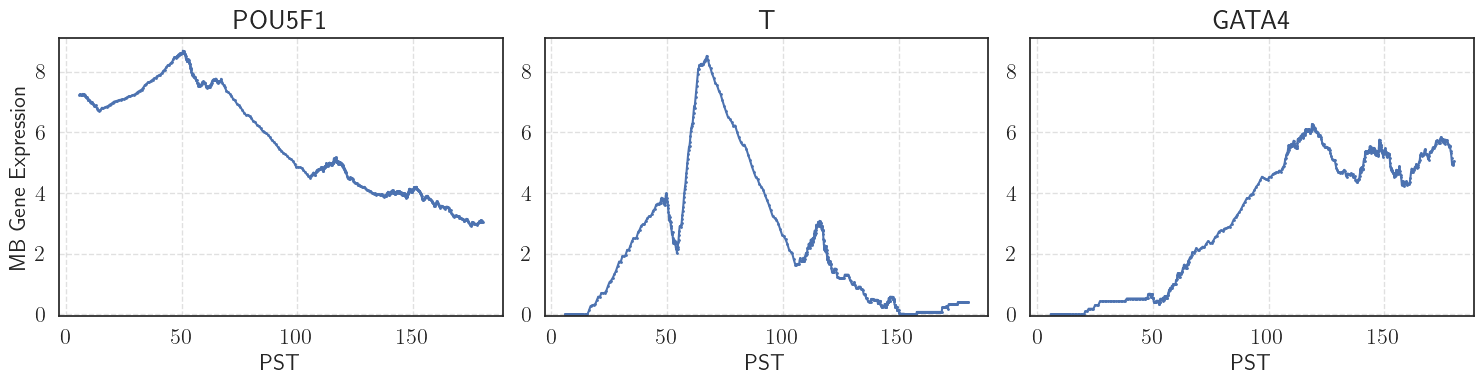

In [19]:
genes_in_time = ["POU5F1", "T", "GATA4"]

y_max = df_lN_mb_pst.loc[genes_in_time].max().max()

fig, axes = plt.subplots(1, len(genes_in_time), figsize=(15, 4), sharex=True)

for i, gene in enumerate(genes_in_time): 
    axes[i].plot(pst_mb_avg, df_lN_mb_pst.loc[gene], marker="o", linestyle="-", markersize=1)
    axes[i].set_title(gene, fontsize=20, fontname='Arial')
    axes[i].set_xlabel("PST", fontsize=16, fontname='Arial')
    axes[i].tick_params(axis='both', labelsize=16)
    axes[i].set_ylim(-0.05, y_max * 1.05)
    
    for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
        label.set_fontname('Arial')
        
    axes[i].grid(True, linestyle="--", alpha=0.6)

axes[0].set_ylabel("MB Gene Expression", fontsize=16, fontname='Arial')

plt.tight_layout()
fig.savefig(path_human_fig+"Fig6/expression_in_pst_eg.svg", format="svg")
plt.show()

### CLUSTER LABELS

In [20]:
# load from input_data folder the pst values per each cell: pseudotime_hPSCs_ordered.txt
cl_labels = np.loadtxt(path + "/input_data/marker_genes/by_cluster/cl_labels_hPSCs_ordered_by_pst.txt", dtype=float)

# averaging the pseudotime array
cl_labels_avg = np.array(pd.DataFrame(cl_labels).rolling(window=mb_wind).mean().dropna()).flatten()

In [21]:
from scipy.stats import mode

# Function to compute mode or retain the unique value
def rolling_mode_or_unique(series):
    unique_values = np.unique(series)
    if len(unique_values) == 1:
        return unique_values[0]  # Return the unique value if all are the same
    else:
        return mode(series, nan_policy='omit').mode[0]  # Return the mode otherwise

# Apply rolling logic
mb_wind = 50  # Example window size
cl_labels_avg = (
    pd.DataFrame(cl_labels)
    .rolling(window=mb_wind)
    .apply(rolling_mode_or_unique, raw=True)
    .dropna()
    .to_numpy()
    .flatten()
)
cl_labels_avg.shape

/var/folders/2z/hsgwjl3d49109llzgvkyf6jw0000gn/T/ipykernel_27081/2977497588.py:9: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  return mode(series, nan_policy='omit').mode[0]  # Return the mode otherwise


(709,)

In [22]:
cl_labels_avg[cl_labels_avg==5]=12
cl_labels_avg[cl_labels_avg==2]=11
cl_labels_avg[cl_labels_avg==6]=7
cl_labels_avg[cl_labels_avg==1]=8
cl_labels_avg[cl_labels_avg==3]=9
cl_labels_avg[cl_labels_avg==4]=10
cl_labels_avg = cl_labels_avg-6

# Merging cluster 5 and 6
cl_labels_avg[cl_labels_avg==6]=5

np.unique(cl_labels_avg)




array([1., 2., 3., 4., 5.])

### Binarisation

In [23]:
spins_df_lN_mb_pst = funcs_general.binarization(df_lN_mb_pst, thr=thr)

### Remove static genes GA

In [24]:
# Function to check if at least 90% of the elements in a row are the same
# and return the most repeated value and its percentage if the condition is satisfied
def check_row_majority(row):
    # Count the occurrences of each unique value in the row
    value_counts = row.value_counts()
    # Get the most frequent value and its count
    most_frequent_value = value_counts.idxmax()
    most_frequent_count = value_counts.max()
    # Calculate the proportion of the most frequent value
    proportion = most_frequent_count / len(row)
    # Check if the proportion is >= 100%
    if proportion >= 1:
        return most_frequent_value, proportion  # Return the value and its proportion
    else:
        return None  # Return None if the condition is not met

# Apply the function to each row of the DataFrame
results = spins_df_lN_mb_pst.apply(check_row_majority, axis=1)

# Filter rows that satisfy the condition
rows_with_majority = results.notnull()

# Print the indices, most repeated value, and percentage for rows that satisfy the condition
print("Rows that satisfy the criterion (at least 90% of the elements are the same):")
for idx in spins_df_lN_mb_pst[rows_with_majority].index:
    value, proportion = results[idx]
    print(f"Row {idx}: Most repeated value = {value}, Percentage = {proportion * 100:.2f}%")
    


Rows that satisfy the criterion (at least 90% of the elements are the same):
Row CSDA: Most repeated value = 1.0, Percentage = 100.00%
Row SKIL: Most repeated value = 1.0, Percentage = 100.00%
Row SOX4: Most repeated value = 1.0, Percentage = 100.00%
Row TP53: Most repeated value = 1.0, Percentage = 100.00%
Row YBX1: Most repeated value = 1.0, Percentage = 100.00%
Row ZIC2: Most repeated value = 1.0, Percentage = 100.00%


In [25]:
# # print the gene expression in time of spins_df_lN_mb_pst[rows_with_majority].index
# genes_always_on = np.array(spins_df_lN_mb_pst[rows_with_majority].index)
# df_max = df_lN_mb_pst.loc[genes_always_on].max(axis=1)
# for gene in genes_always_on:
#     plt.figure(figsize=(4, 3))
#     plt.plot(df_lN_mb_pst.loc[gene].values, color='salmon')
#     plt.title(gene)
#     plt.xlabel("Cells ordered by Pseudotime", fontsize=9)
#     plt.ylabel("gene expression", fontsize=9)
#     plt.xticks(fontsize=8)
#     plt.yticks(fontsize=8)
#     plt.hlines(df_max[df_max.index==gene].values*0.5, 0, len(df_lN_mb_pst.loc[gene].values), color='black', linestyle='--')
#     plt.show()
    


In [26]:
# remove_always_on = False
# if remove_always_on:
#     # remove genes_always_on from spins_df_lN_mb_pst and genes_relevant
#     spins_df_lN_mb_pst = spins_df_lN_mb_pst.drop(genes_always_on)   
#     df_lN_mb_pst = df_lN_mb_pst.drop(genes_always_on)
#     genes_relevant = np.setdiff1d(genes_relevant, genes_always_on)

# # check dimensions spins_df_lN_mb_pst and genes_relevant
# print("shape of the lognorm ge for selected genes (MB):", df_lN_mb_pst.shape)
# print("shape of the lognorm ge for selected genes (MB) after removing the genes_always_on:", spins_df_lN_mb_pst.shape)
# print("length of genes_relevant after removing the genes_always_on:", len(genes_relevant))

## INPUT GA

#### Clustering by genes

In [27]:
# by genes clustering
row_linkage = scipy.cluster.hierarchy.linkage(spins_df_lN_mb_pst, method='ward')

# g = sns.clustermap(spins_df_lN_mb_pst, row_linkage=row_linkage, cmap='YlGnBu',
#                    yticklabels=genes_relevant, cbar_pos=None,  # Usa cbar_pos=None per rimuovere la colorbar
#                    figsize=(6,12), row_cluster=True, col_cluster=False, xticklabels=False)

# # Cambiare la dimensione del font per le etichette delle y-tick
# g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)

# # Mostrare la figura
# plt.show()



In [28]:
# check if there are rows that are =-1 or +1 for more than 90% of the columns
genes_to_remove = []
for gene in spins_df_lN_mb_pst.index:
    if (spins_df_lN_mb_pst.loc[gene] == -1).sum() > 0.95 * spins_df_lN_mb_pst.shape[1]:
        genes_to_remove.append(gene)
    if (spins_df_lN_mb_pst.loc[gene] == 1).sum() > 0.95 * spins_df_lN_mb_pst.shape[1]:
        genes_to_remove.append(gene)
len(genes_to_remove)
genes_to_remove

['CSDA', 'SKIL', 'SMAD2', 'SOX11', 'SOX4', 'TP53', 'YBX1', 'ZIC2']

### Clustering by cells

In [29]:
# Calculate the z-spins for the rows (not the columns)
col_linkage = scipy.cluster.hierarchy.linkage(spins_df_lN_mb_pst.T, method='ward')
# g = sns.clustermap(spins_df_lN_mb_pst,col_linkage=col_linkage, cmap='YlGnBu',
#                    yticklabels=genes_relevant, cbar_pos=None,  # Use cbar_pos=None to remove the colorbar
#                    figsize=(7, 12), row_cluster=False, col_cluster=True, xticklabels=False)

# g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
# plt.show()

#### Ordered by PST

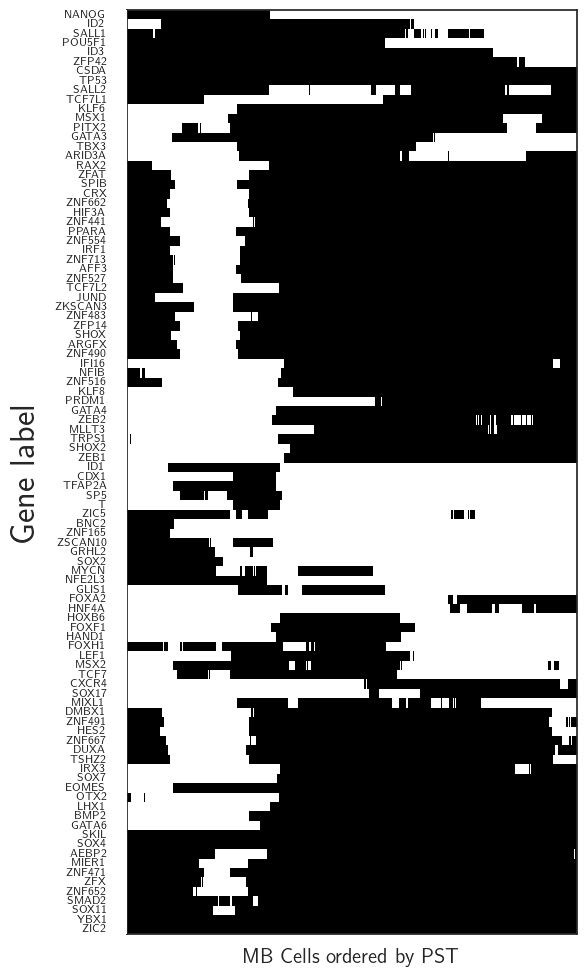

In [30]:
spins_ordered = spins_df_lN_mb_pst.loc[genes_reordered_clust]
genes_reordered = genes_reordered_clust  # solo per chiarezza

# Plot
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 12))

# Usa colormap bianco→nero
figs_funcs.raster_plot(np.array(spins_ordered), ax, '', 1, genes_reordered)

# Barra laterale
divider = make_axes_locatable(ax)
line_ax = divider.append_axes("left", size=0.15, pad=0, sharey=ax)
line_ax.set_xlim(0, 1)
line_ax.set_ylim(ax.get_ylim())
line_ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
for spine in ['left', 'right', 'top', 'bottom']:
    line_ax.spines[spine].set_visible(False)

# Etichette
ax.set_yticks(np.arange(len(genes_reordered)))
ax.set_yticklabels(genes_reordered, fontsize=8, ha='right', va='center')
ax.set_xlabel("MB Cells ordered by PST", fontsize=15)
ax.tick_params(axis='y', pad=9)

fig.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS7/F_human_ga.tiff", 
            dpi=300, 
            bbox_inches='tight')
plt.show()

In [31]:
funcs_general.check_index(spins_df_lN_mb_pst.index, genes_relevant)

True


## Randomization

In [32]:
# number of resulting shuffled data
N_test = 250

N_rows = spins_df_lN_mb_pst.shape[0]
N_cols = spins_df_lN_mb_pst.shape[1]

# Linearize
val_rnd = np.reshape(np.array(spins_df_lN_mb_pst), (N_cols*N_rows))

# reshuflle for N_test times
spins_df_lN_mb_pst_shuffle = np.zeros((N_test, N_rows, N_cols))

for ii in range(N_test):
    np.random.seed(1234+ii)
    # Random reshuffle of the binnarized GE data
    np.random.shuffle(val_rnd)
    val_rnd_matx = val_rnd.reshape(N_rows,N_cols) # Reshape to the original shape
    trial_long = pd.DataFrame(val_rnd_matx)

    # Save the shuffled DataFrame
    spins_df_lN_mb_pst_shuffle[ii,:,:] = trial_long
    
print(f"shape of the shuffled data: {spins_df_lN_mb_pst_shuffle.shape}")
    

shape of the shuffled data: (250, 98, 709)


In [33]:
# funcs_general.check_shuffle(spins_df_lN_mb_pst_shuffle, N_test)

In [34]:
show_fig = False
if show_fig:
    for ii in range(0, 1):
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,7))
        figs_funcs.raster_plot(np.array(spins_df_lN_mb_pst_shuffle[ii,:,:]), ax, 'Discretization of LogNorm data with PST and MB - RND '+str(ii+1), 1, genes_relevant[::-1])
        plt.show()    

## Experimental data

### Known interactions

In [35]:
# # Interaction from SCODE SM fig 3a
literature_based_interactions = ["NANOG GATA6 -1", "NANOG GATA4 -1", 
                "POU5F1 GATA6 -1", "POU5F1 T -1", "POU5F1 EOMES -1", 
                "POU5F1 ID2 -1", "POU5F1 SOX2 1"]



### Experimental KO log2FC

#### Yilmaz

Yilmaz A, Braverman-Gross C, Bialer-Tsypin A, Peretz M et al. Mapping Gene Circuits Essential for Germ Layer Differentiation via Loss-of-Function Screens in Haploid Human Embryonic Stem Cells. Cell Stem Cell 2020 Oct 1;27(4):679-691.e6. PMID: 32735778

In [36]:
# df_KO_log2FC = pd.read_csv("input_data/ko_data/df_ordered_log2FC_Ylmaz.csv", index_col=0, header=0)
# print(df_KO_log2FC.shape)
# df_KO_log2FC.head(3)

# # remove first col
# # df_KO_log2FC = df_KO_log2FC.drop(columns="DE")

In [37]:
# # remove the first column (DE log2FC)
# df_KO_log2FC = df_KO_log2FC.iloc[:, 1:].copy()

# # rename the columns of df_KO_log2FC_common
# df_KO_log2FC.columns = ["GLIS1", "HNF4A"]
# df_KO_log2FC = df_KO_log2FC.rename(index={"TBXT": "T"})


In [38]:
# plt.figure(figsize=(4,12))

# sns.heatmap(np.array(df_KO_log2FC).astype(float), annot=True, fmt=".2f", 
#             xticklabels=df_KO_log2FC.columns, yticklabels=df_KO_log2FC.index, 
#             cmap="coolwarm", cbar=True, center=0, linewidth=.5, annot_kws={"size":6, 'color':'black'},
#             cbar_kws={'shrink': 0.8, 'aspect': 80})  # Regola la dimensione e l'aspetto della colorbar

# plt.xticks(fontsize=8)
# plt.yticks(fontsize=8)
# plt.title("Log2FC", fontsize=10)

# plt.show()

In [39]:
# # normalize before plotting dividing by the max value of the df 
# df_KO_log2FC_norm = df_KO_log2FC / df_KO_log2FC.abs().max().max()


# plt.figure(figsize=(15, 2))  # Adjusted figsize for horizontal layout

# sns.heatmap(np.array(df_KO_log2FC_norm).astype(float).T,  # Transpose the data
#             annot=True,
#             fmt=".2f", 
#             xticklabels=df_KO_log2FC_norm.index, 
#             yticklabels=df_KO_log2FC_norm.columns, 
#             cmap="coolwarm", 
#             cbar=True, 
#             center=0, 
#             linewidth=.5, 
#             annot_kws={"size": 5, 'color': 'black', "rotation": 90},
#             cbar_kws={'label': 'Log2FC Norm', 'shrink': 0.7, 'aspect': 20})  

# plt.xticks(fontsize=7, rotation=90)  
# plt.yticks(fontsize=8, rotation=90)
# # plt.title("Log2FC", fontsize=10)

# plt.show()

# Grid search for _hyperparameters_

In [40]:
# Defining a dictionary of hyperparameters for grid search
params = {"LAMBDA": [0.01, 0.02, 0.03, 0.04, 0.05, 0.07, 0.09],
          "lr": [0.8, 0.7, 0.6, 0.5, 0.4, 0.3],
          "drop": [0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99],
          "edrop": [15, 20, 25, 30, 35],
          "opt": ['MOMENTUM', 'NADAM'],
          "MOM": [0.75, 0.8, 0.85, 0.9, 0.95, 0.99],
          "reg": ['L1'],
          "Nepochs": [500, 700, 800, 900, 1200]}


## Hyperparameter space 

/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


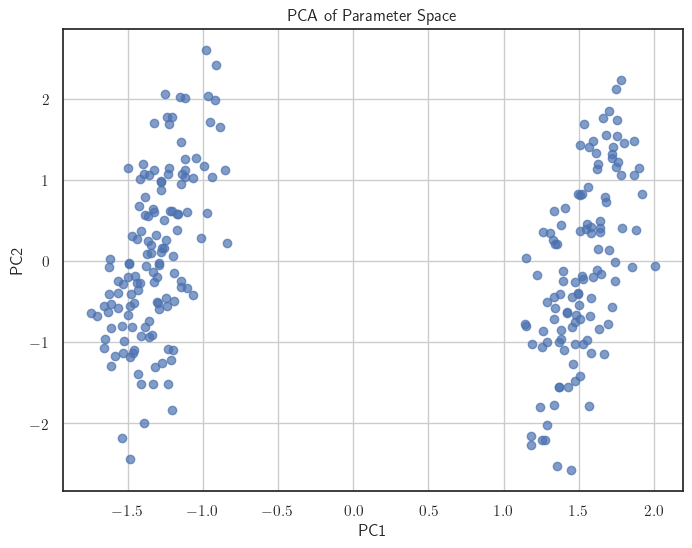

In [41]:
def regenerate_params(seed, params, Ntrials):
    """
    Regenerate the same set of parameters using a fixed seed.
    
    Parameters:
        seed (int): The random seed to ensure reproducibility.
        params (dict): The dictionary of parameters with keys as names and 
                       values as lists of possible options.
        Ntrials (int): Number of parameter sets to generate.
    
    Returns:
        list: A list of dictionaries, each containing a set of generated parameters.
    """
    np.random.seed(seed)  # Set the seed for reproducibility
    param_sets = [
        {key: np.random.choice(value) for key, value in params.items()}
        for _ in range(Ntrials)
    ]
    return param_sets

# Generate the parameter sets
seed = 12345
Ntrials = 250
param_sets = regenerate_params(seed, params, Ntrials)
df_params = pd.DataFrame(param_sets)

# One-hot encoding for the categorical columns
categorical_cols = ['opt', 'reg']
encoder = OneHotEncoder(sparse=False)
encoded_categorical = encoder.fit_transform(df_params[categorical_cols])
encoded_categorical = pd.DataFrame(
    encoded_categorical, columns=encoder.get_feature_names_out(categorical_cols)
)
df_numeric = df_params.drop(columns=categorical_cols)
df_final = pd.concat([df_numeric.reset_index(drop=True), encoded_categorical], axis=1)

# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_final)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.7)
plt.title("PCA of Parameter Space")
plt.xlabel("PC1")

plt.ylabel("PC2")
plt.grid(True)
plt.show()


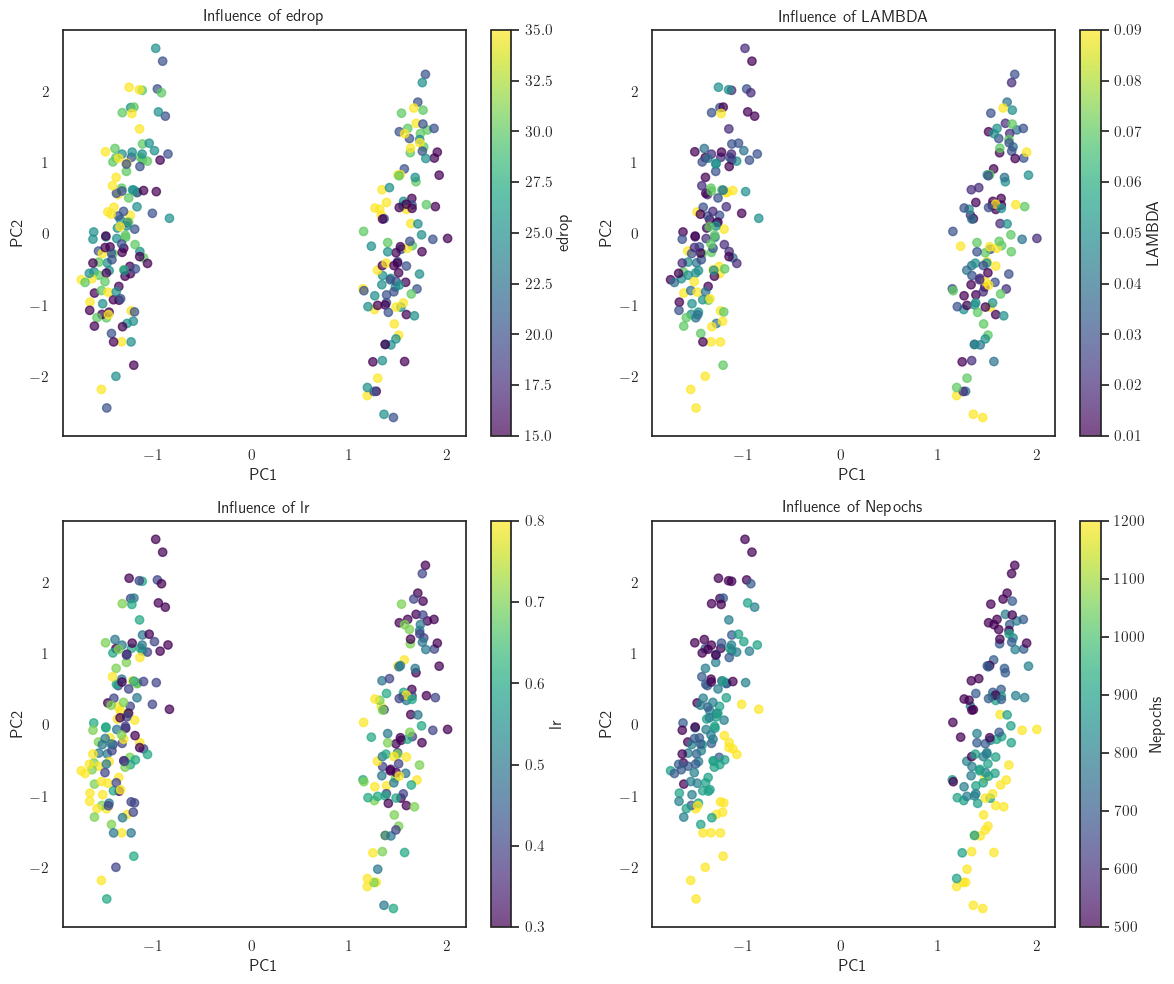

In [42]:
# Visualize the different parameter influence
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# edrop
sc1 = axs[0, 0].scatter(pca_result[:, 0], pca_result[:, 1], c=df_params['edrop'], cmap='viridis', alpha=0.7)
fig.colorbar(sc1, ax=axs[0, 0], label='edrop')
axs[0, 0].set_xlabel("PC1")
axs[0, 0].set_ylabel("PC2")
axs[0, 0].set_title("Influence of edrop")

# LAMBDA
sc2 = axs[0, 1].scatter(pca_result[:, 0], pca_result[:, 1], c=df_params['LAMBDA'], cmap='viridis', alpha=0.7)
fig.colorbar(sc2, ax=axs[0, 1], label='LAMBDA')
axs[0, 1].set_xlabel("PC1")
axs[0, 1].set_ylabel("PC2")
axs[0, 1].set_title("Influence of LAMBDA")

# lr
sc3 = axs[1, 0].scatter(pca_result[:, 0], pca_result[:, 1], c=df_params['lr'], cmap='viridis', alpha=0.7)
fig.colorbar(sc3, ax=axs[1, 0], label='lr')
axs[1, 0].set_xlabel("PC1")
axs[1, 0].set_ylabel("PC2")
axs[1, 0].set_title("Influence of lr")

# Nepochs
sc4 = axs[1, 1].scatter(pca_result[:, 0], pca_result[:, 1], c=df_params['Nepochs'], cmap='viridis', alpha=0.7)
fig.colorbar(sc4, ax=axs[1, 1], label='Nepochs')
axs[1, 1].set_xlabel("PC1")
axs[1, 1].set_ylabel("PC2")
axs[1, 1].set_title("Influence of Nepochs")

plt.tight_layout()
plt.show()

## Random search in params space

In [43]:
cm_original_lN = np.corrcoef(spins_df_lN_mb_pst)
corr_matxs_rnd_lN = np.array([np.corrcoef(spins_df_lN_mb_pst_shuffle[i, :, :]) for i in range(N_test)])
noise_distances = np.array([
    funcs_ko.sum_squared_abs_diff(cm_original_lN, corr_matxs_rnd_lN[i, :, :]) 
    for i in range(N_test)
])

# mean and error of the mean
mu = np.mean(noise_distances)
sigma = np.std(noise_distances)


/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


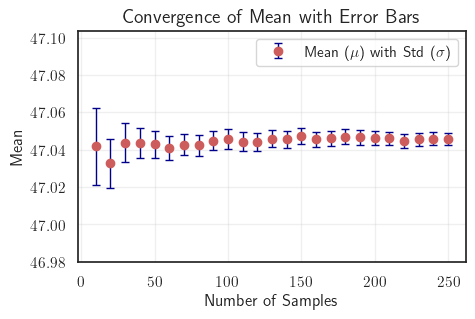

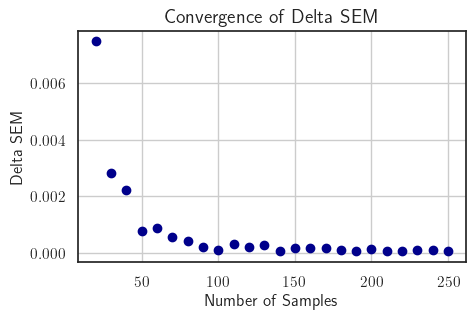

In [44]:
# Compute convergence of mean and standard deviation
means = []
stds = []
sample_sizes = range(10, N_test + 1, 10)  # Test increasing sample sizes

for size in sample_sizes:
    subset_distances = noise_distances[:size]
    # print(f"dimension of subset_distances: {np.std(subset_distances) / np.sqrt(size)}")
    means.append(np.mean(subset_distances))
    stds.append(np.std(subset_distances) / np.sqrt(size))
    # print(np.std(subset_distances), np.sqrt(size))
# Plot the convergence of mean with error bars (sigma as error)
plt.figure(figsize=(5, 3))
plt.errorbar(sample_sizes, means, yerr=stds, fmt='o', 
             color='indianred', ecolor='darkblue', 
             elinewidth=1, capsize=3, label='Mean ($\\mu$) with Std ($\\sigma$)')
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Mean', fontsize=12)
plt.title('Convergence of Mean with Error Bars', fontsize=14)
plt.legend()
plt.ylim(means[0]-3*stds[0], means[0]+3*stds[0])
plt.grid(alpha=0.3)
plt.show()

# delta SEM
delta_SEM = abs(np.array(stds[1:])-np.array(stds[:-1]) )
plt.figure(figsize=(5,3))
plt.plot(sample_sizes[1:], delta_SEM, 'o', color='darkblue', label='Delta SEM')
plt.title('Convergence of Delta SEM', fontsize=14)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Delta SEM', fontsize=12)
plt.grid()


In [45]:
def find_minimum_N_test_for_sem_with_delta_check(distances, sem_threshold=0.01, delta_N=10, delta_sem_threshold=1e-4):
    """
    Finds the minimum N_test such that the Standard Error of the Mean (SEM)
    is below the given threshold, with an additional check for SEM stability.

    Parameters:
    - distances: list or array of precomputed distances
    - sem_threshold: SEM threshold (e.g., 1% of the mean)
    - delta_N: step size for incrementing the test
    - delta_sem_threshold: threshold for relative change in SEM between steps

    Returns:
    - minimum_N_test: the smallest N_test satisfying both SEM and delta SEM conditions
    """
    current_N = 0  # Initialize sample count
    previous_sem = None  # Track the SEM from the previous step

    while current_N < len(distances):
        # Increment the current number of samples
        current_N += delta_N

        # Use the first `current_N` distances
        subset_distances = distances[:current_N]

        # Calculate mean and standard deviation for the subset
        mu = np.mean(subset_distances)
        sigma = np.std(subset_distances)

        # Calculate SEM
        sem = sigma / np.sqrt(current_N)

        # Check if SEM is below the threshold
        if sem < sem_threshold * mu:  # Relative to the mean
            # Check delta SEM stability
            if previous_sem is not None:
                delta_sem = abs(sem - previous_sem) #/ sem  # Relative change in SEM
                # print(f"deltaSEM: {delta_sem}")
                if delta_sem < delta_sem_threshold:
                    return current_N  # Return the minimum N_test meeting both conditions

        # Update previous SEM
        previous_sem = sem

    # If no sufficient N_test is found, return the maximum available
    return len(distances)

minimum_N_test_sem = find_minimum_N_test_for_sem_with_delta_check(
    noise_distances,
    sem_threshold=1e-4,       # SEM threshold relative to the mean
    delta_N=10,               # Incremental step
    delta_sem_threshold=1e-4  # Relative change threshold for SEM
)
print(f"The minimum N_test for SEM and delta SEM is: {minimum_N_test_sem}")

The minimum N_test for SEM and delta SEM is: 140


In [46]:
# unique_patterns = np.unique(spins_df_lN_mb_pst, axis=1)
# print(f"Number of unique patterns: {unique_patterns.shape[1]}")

# N_total = unique_patterns.shape[1]  # Unique patterns
# P_target = 0.8  # Desired probability of covering all patterns
# N_cells_min = int(N_total * np.log(N_total / (1 - P_target)))

# round_N_cells_min = N_cells_min#-(-N_cells_min // 1000) * 1000
# print(f"Estimated minimum N_cells: {round_N_cells_min}")


In [47]:
# spins_df_lN_mb_pst_shuffle = spins_df_lN_mb_pst_shuffle[:minimum_N_test_sem, :, :]
if minimum_N_test_sem < 150: 
    N_test=150
else:
    N_test = minimum_N_test_sem

Ntimes = spins_df_lN_mb_pst.shape[1] # Ntimes = round_N_cells_min
spins_df_lN_mb_pst_shuffle = spins_df_lN_mb_pst_shuffle[:N_test, :, :].copy()

print(f"Selected N_test: {N_test} \nNtimes: {Ntimes}")

Selected N_test: 150 
Ntimes: 709


## Random search execution

In [48]:
N_rnd_search = 250

data_type = "output_data/ignite_hESCs"

today = "2024_12_10_no_scode_t"+str(Ntimes)+"_Ntest"+str(N_test)+"_cmd_sel_new" 



In [49]:
# from above, in df randomization, N_test = 150 
print(N_test)
print(spins_df_lN_mb_pst_shuffle.shape)
print(spins_df_lN_mb_pst.shape)

150
(150, 98, 709)
(98, 709)


In [50]:
# Calculating correlation matrices and distance for 'No Prior' model computation (i.e. not known prior interactions)
corr_matxs_rnd_lN = corr_matxs_rnd_lN[:N_test, :, :].copy()
noise_dist = np.mean([funcs_ko.sum_squared_abs_diff(cm_original_lN, corr_matxs_rnd_lN[i,:,:]) for i in range(N_test)])

In [51]:
# Performing grid search and storing results
compute = False # Change to True to compute the results. 
saving = False # Change to True to save the results. WARNING: This will overwrite the previous results if the date is not changed

if compute:
    start_time = time.time()
    grn_sel, fci_sel, cmd_sel, models = funcs_grn_search.grid_search(np.array(spins_df_lN_mb_pst), params, [],#literature_based_interactions, 
                                                                    genes_relevant, Ntrials = N_rnd_search, Nshuffle = N_test, 
                                                                    Ntimes = Ntimes,
                                                                    seedSet=12345, 
                                                                    cm_original_lN=cm_original_lN, 
                                                                    noise_dist=noise_dist)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Total time: {elapsed_time/3600:.2f} hours")
    
    if saving:
        print("name of the saved file: ", data_type+'_'+str(today)+'.npz')  
        np.savez(data_type+str(today)+'.npz', array_1=grn_sel, array_2=fci_sel, array_3=cmd_sel, array_4=models)

else: 
    # Loading previously computed data 
    lN_arrays = np.load("./"+data_type+str(today)+'.npz', allow_pickle=True)
    grn_sel = lN_arrays['array_1']
    fci_sel = lN_arrays['array_2']
    cmd_sel = lN_arrays['array_3']
    models = lN_arrays['array_4']



### Performance of the results in params space

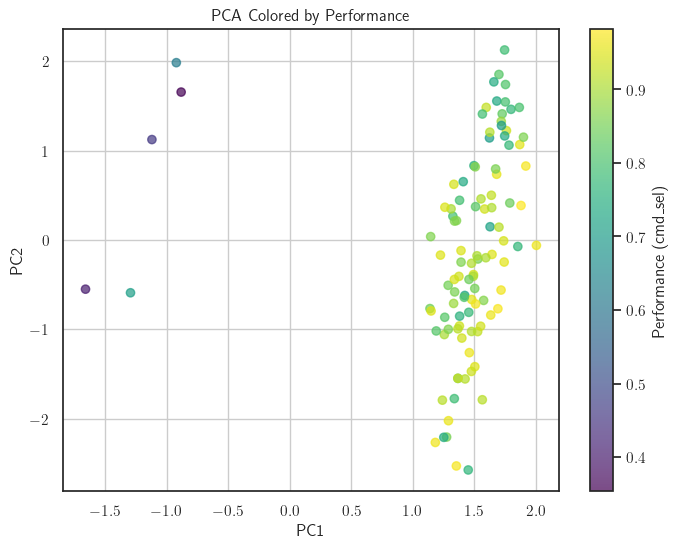

Number of non-nan cmd_sel: 106


In [52]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_result[:, 0], pca_result[:, 1],
    c=cmd_sel, cmap='viridis', alpha=0.7
)
plt.colorbar(scatter, label='Performance (cmd_sel)')
plt.title("PCA Colored by Performance")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# non nan cmd_sel
print("Number of non-nan cmd_sel:", np.sum(~np.isnan(cmd_sel)))

In [53]:
# Loadings (contributi dei parametri alle componenti principali)
loadings = pd.DataFrame(pca.components_, columns=df_final.columns, index=['PC1', 'PC2'])
print(loadings)

       LAMBDA        lr      drop     edrop       MOM   Nepochs  opt_MOMENTUM  \
PC1 -0.002470 -0.092872  0.032931 -0.035882  0.163951  0.031822      0.693219   
PC2 -0.274352 -0.330783 -0.115608  0.176126  0.613541 -0.619386     -0.073679   

     opt_NADAM  reg_L1  
PC1  -0.693219    -0.0  
PC2   0.073679     0.0  


In [54]:
# Counting and printing the number of NaN values in the distance matrix
nan_count = np.sum(np.isnan(cmd_sel))
print("Number of NaN in cmd_sel: ", nan_count)


Number of NaN in cmd_sel:  144


# IGNITE RESULTS 

## CMD Performances & GRN selection

In [55]:
# select models with lowest lN_dist, distance between Orig and Exp Pearson matrices
Nmodel_CMD = 10
idxs_sel_CMD = np.argsort(cmd_sel)[:Nmodel_CMD]

for jj in idxs_sel_CMD:
    print ("selected idx for CMD:", jj,
           f"- CMD value, {cmd_sel[jj]:.3f}")


selected idx for CMD: 38 - CMD value, 0.354
selected idx for CMD: 164 - CMD value, 0.402
selected idx for CMD: 131 - CMD value, 0.459
selected idx for CMD: 98 - CMD value, 0.619
selected idx for CMD: 143 - CMD value, 0.699
selected idx for CMD: 114 - CMD value, 0.700
selected idx for CMD: 101 - CMD value, 0.707
selected idx for CMD: 202 - CMD value, 0.718
selected idx for CMD: 15 - CMD value, 0.722
selected idx for CMD: 97 - CMD value, 0.734


In [56]:
# Decide which model selection we want to analyse
idxs_sel = idxs_sel_CMD.copy()

model_idx_sel = idxs_sel[0]
print("Selected model index:", model_idx_sel)

Nmodel_sel = len(idxs_sel)
print("# selected  models, ", Nmodel_sel)


Selected model index: 38
# selected  models,  10


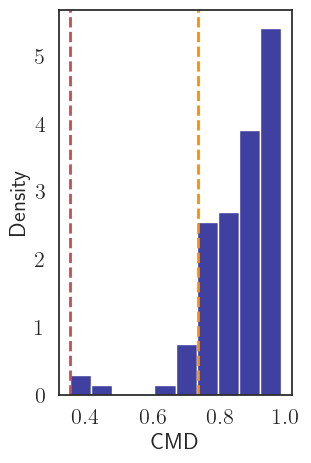

In [57]:
# plot the distribution of cmd_sel
plt.figure(figsize=(3,5))
sns.histplot(cmd_sel,bins=10, color='navy', stat='density')
plt.axvline(cmd_sel[model_idx_sel], color='r', linestyle='--', linewidth=2, label="CMD - best GRN")
plt.axvline(cmd_sel[idxs_sel_CMD[-1]], color='darkorange', linestyle='--', linewidth=2, label="CMD - 10th best GRN")

# plt.legend(fontsize=12, loc='upper left')
plt.xlabel("CMD", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig(f"/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/cmd_distribution_"+str(len(cmd_sel))+".svg", format="svg")


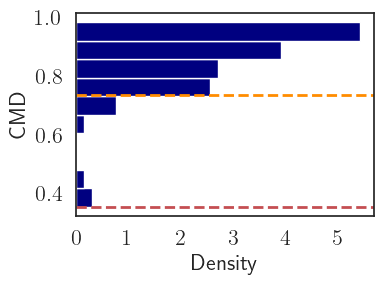

In [58]:
plt.figure(figsize=(4, 3))
plt.hist(cmd_sel, bins=10, color='navy', density=True, orientation='horizontal')

plt.axhline(cmd_sel[model_idx_sel], color='r', linestyle='--', linewidth=2, label="CMD - best GRN")
plt.axhline(cmd_sel[idxs_sel_CMD[-1]], color='darkorange', linestyle='--', linewidth=2, label="CMD - 10th best GRN")

plt.ylabel("CMD", fontsize=16)
plt.xlabel("Density", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.savefig(f"/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/cmd_distribution_"+str(len(cmd_sel))+".svg", format="svg")


## Selected GRN

max abs value of the matrix: 5.26985574126805
max abs value of the matrix: 5.26985574126805


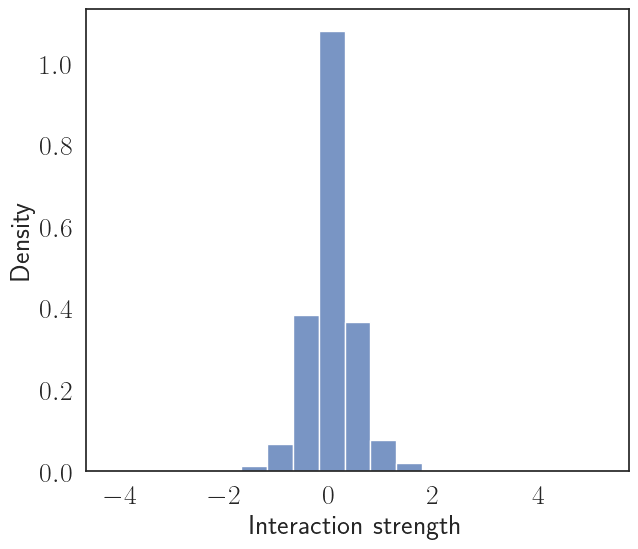

In [59]:
best_model_sel = np.squeeze(grn_sel[model_idx_sel,:,:])

best_model_nodiag = best_model_sel.copy()
print("max abs value of the matrix:", np.max(np.abs(best_model_nodiag)))
np.fill_diagonal(best_model_nodiag, 0)
print("max abs value of the matrix:", np.max(np.abs(best_model_nodiag)))

plt.figure(figsize=(7,6))
bins = np.linspace(np.ndarray.flatten(best_model_nodiag).min(), np.ndarray.flatten(best_model_nodiag).max(), 20)
sns.histplot(np.ndarray.flatten(best_model_nodiag), stat="density", bins=bins)
plt.ylabel("Density", fontsize=20)
plt.xlabel("Interaction strength", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()
plt.close()  




<Figure size 500x500 with 0 Axes>

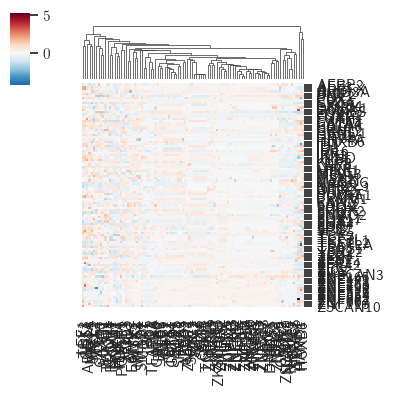

<Figure size 1600x1400 with 0 Axes>

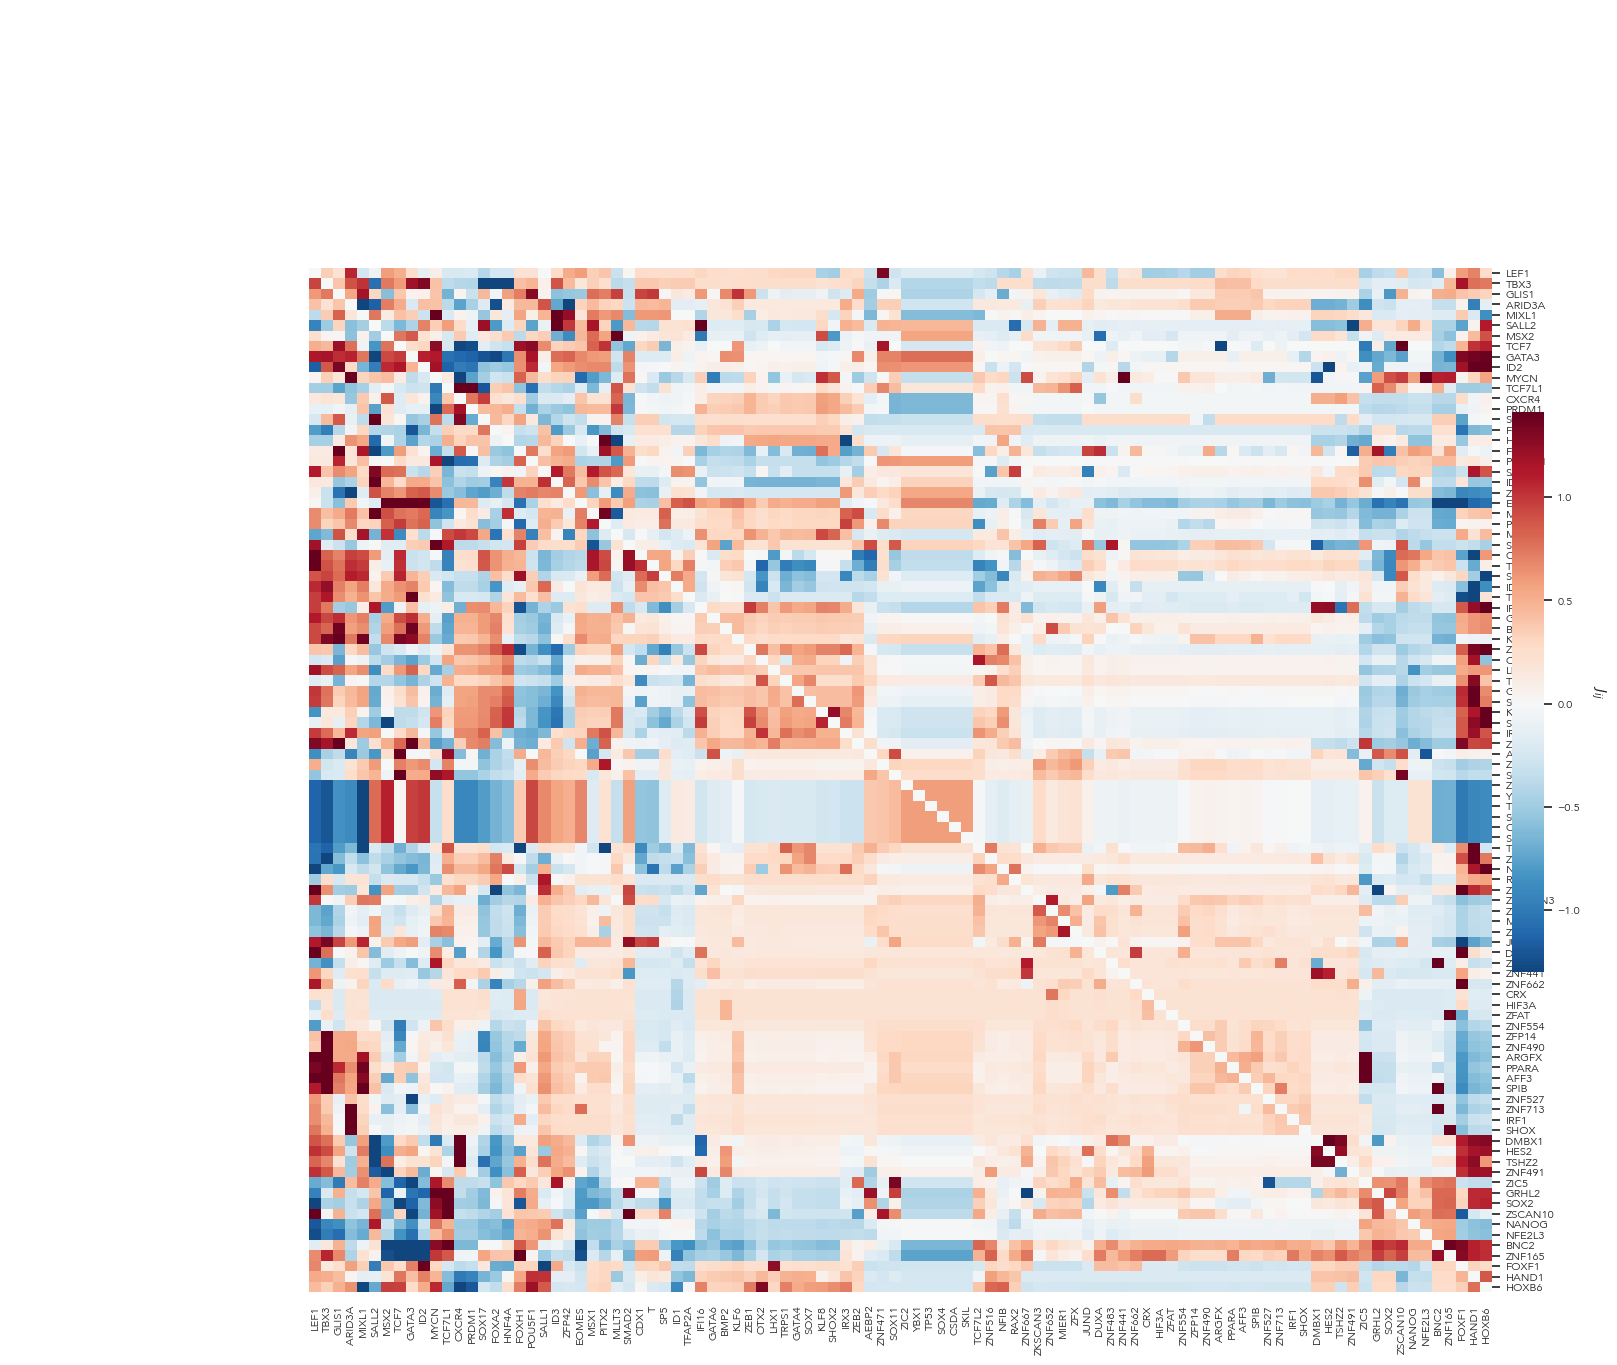

In [60]:
def plotmat(m, ax_names, text, cmap='RdBu_r', figsize=(16, 14)):
    # Convert the matrix to a DataFrame with appropriate row and column names
    df = pd.DataFrame(m, index=ax_names, columns=ax_names)

    plt.figure(figsize=(5,5))
    # Create a clustered heatmap
    g = sns.clustermap(df, cmap=cmap, figsize=(4,4), 
                       row_cluster=False,  # Initially keep row clustering off
                       col_cluster=True, 
                       xticklabels=True,
                       yticklabels=True,
                       center=0);
    plt.show();

    # Get the column order after clustering
    col_order = g.dendrogram_col.reordered_ind
    # Reorder the rows to match the columns
    df_reordered = df.iloc[col_order, col_order]

    plt.figure(figsize=figsize)
    plt.rcParams['font.family'] = 'Avenir'
    plt.rcParams['text.usetex'] = False
    # Plot the reordered heatmap (both rows and columns now match the clustering)
    mean_J = np.mean(m)
    std_J = np.std(m)
    # Plot the reordered heatmap (both rows and columns now match the clustering)
    # g = sns.clustermap(df_reordered, cmap=cmap, figsize=figsize, 
    #                 row_cluster=False, 
    #                 col_cluster=False,
    #                 xticklabels=True,
    #                 yticklabels=True,
    #                 center=0,
    #                 vmin=mean_J - 3 * std_J,
    #                 vmax=mean_J + 3 * std_J,
    #                 cbar_pos=(1., 0.13, 0.015, 0.6))  # (x, y, width, height) in figure coords
    g = sns.clustermap(df_reordered, cmap=cmap, figsize=figsize,
                   row_cluster=False,
                   col_cluster=False,
                   xticklabels=True,
                   yticklabels=True,
                   center=0,
                   vmin=mean_J - 3 * std_J,
                   vmax=mean_J + 3 * std_J)
    min_max_cbar = np.array([mean_J - 3 * std_J, mean_J + 3 * std_J])

    g.cax.set_position([0.95, 0.3, 0.02, 0.4])  # (x, y, width, height) in figure coords

    # Tick labels
    for label in g.ax_heatmap.get_xticklabels():
        label.set_fontsize(8)
        label.set_rotation(90)

    for label in g.ax_heatmap.get_yticklabels():
        label.set_fontsize(8)

    cbar = g.cax  # Get the colorbar axis
    cbar.set_ylabel(r'$J_{ij}$', rotation=270, labelpad=20, fontsize=10)  # Add label to colorbar
    cbar.tick_params(labelsize=8)  # Set font size for colorbar ticks
    # cbar.set_aspect(10)  # Adjust the aspect ratio to make the colorbar narrower
    plt.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/GRN_best_inferred_matrix.svg", format="svg")
    g.figure.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/GRN_best_inferred_matrix.svg", format="svg")
    plt.show()
    
    return col_order, min_max_cbar

best_model_nodiag = best_model_sel.copy()  # Ensure you have your matrix ready
np.fill_diagonal(best_model_nodiag, 0)  # Replace diagonal with zeros

# Call the modified plotmat function
col_order, min_max_cbar = plotmat(best_model_nodiag, genes_relevant, "Heatmap with Clustering")

In [61]:
genes_list = ["POU5F1", "NANOG", "SOX2", "ZIC2",
              "ID1", "ID2", "TFAP2A", "SOX4", 
               "GATA3", 
               "T",
              "EOMES", "MSX1", 
              "GATA4", "GATA6", "OTX2",
              "HAND1", "SOX7", 
              "MIXL1",
              "KLF8", 
              "SOX17", "CXCR4",
               "HNF4A"]

In [62]:
best_model_nodiag = best_model_sel.copy()
np.fill_diagonal(best_model_nodiag, 0)


In [63]:
from matplotlib.colors import Normalize, TwoSlopeNorm
import matplotlib.colors as mcolors

def custom_transform(x, mean_J, std_J):
    """Apply hybrid linear-log transform."""
    upper = mean_J + 1 * std_J
    lower = mean_J - 1 * std_J
    if x > upper:
        return upper + np.log1p(x - upper)
    elif x < lower:
        return lower - np.log1p(lower - x)
    else:
        return x


In [64]:
min_max_cbar

array([-1.29966973,  1.4133546 ])

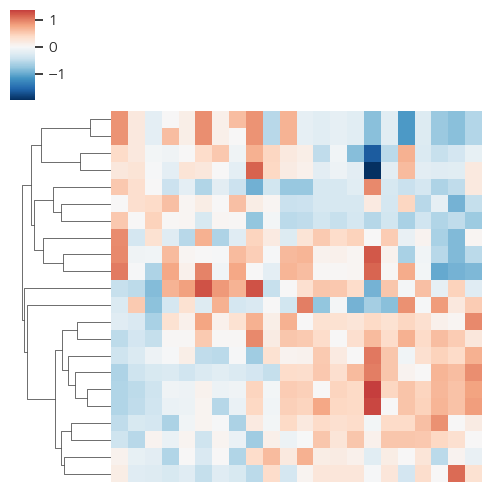

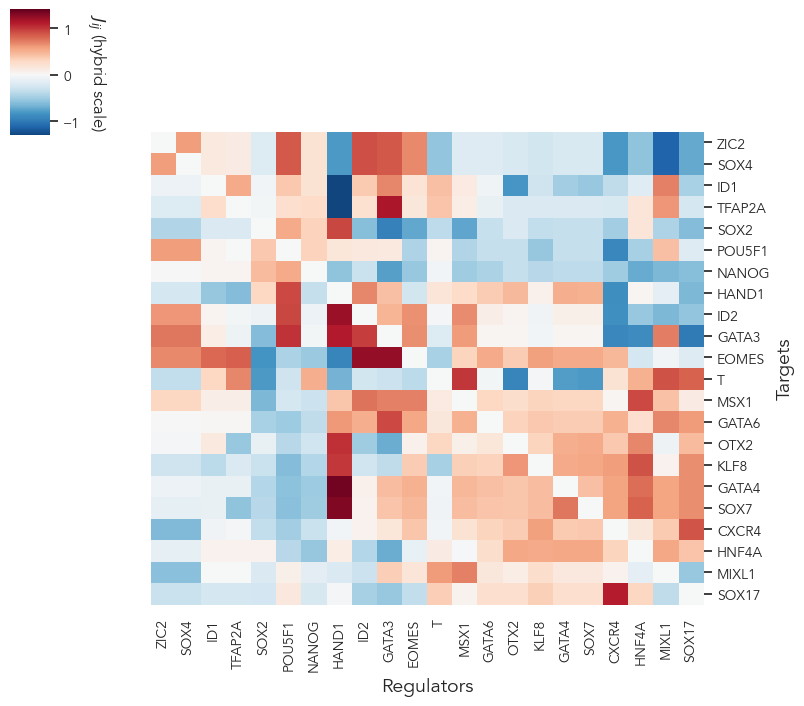

In [65]:

def plot_grouped_heatmap_with_clustering(interaction_matrix, all_genes, sel_genes, min_max_cbar=np.array([-1, 1])):
    if isinstance(all_genes, np.ndarray):
        all_genes = list(all_genes)

    ordered_genes = sel_genes
    gene_indices = [all_genes.index(gene) for gene in ordered_genes if gene in all_genes]
    filtered_matrix = interaction_matrix[np.ix_(gene_indices, gene_indices)]

    mean_J = np.mean(interaction_matrix)
    std_J = np.std(interaction_matrix)
    transformed_matrix = np.vectorize(custom_transform)(filtered_matrix, mean_J, std_J)

    df = pd.DataFrame(transformed_matrix, index=ordered_genes, columns=ordered_genes)

    # Primo clustermap: solo per ottenere l’ordine + dendrogramma visibile
    g1 = sns.clustermap(df, cmap="RdBu_r", figsize=(5, 5),
                        row_cluster=True, col_cluster=False,
                        xticklabels=False, yticklabels=False,
                        center=0)
    # col_order = g1.dendrogram_col.reordered_ind
    row_order = g1.dendrogram_row.reordered_ind
    plt.show()

    # Riordina righe e colonne
    # df_reordered = df.iloc[col_order, col_order]
    # df_reordered = df.iloc[row_order, col_order]
    df_reordered = df.iloc[row_order, row_order]

    # Secondo clustermap: con righe e colonne riordinate (senza nuovo clustering)
    # g2 = sns.clustermap(df_reordered, cmap="RdBu_r", figsize=(8, 7),
    #                     row_cluster=False, col_cluster=False,
    #                     xticklabels=True, yticklabels=True,
    #                     center=0,
    #                     vmin=np.min(transformed_matrix),
    #                     vmax=np.max(transformed_matrix),
    #                     cbar_kws={"label": r"$J_{ij}$ (hybrid scale)"})
    g2 = sns.clustermap(df_reordered, cmap="RdBu_r", figsize=(8, 7),
                    row_cluster=False, col_cluster=False,
                    xticklabels=True, yticklabels=True,
                    center=0,
                    vmin=min_max_cbar[0],
                    vmax=min_max_cbar[1],
                    cbar_kws={"label": r"$J_{ij}$ (hybrid scale)"})

    g2.ax_heatmap.set_xlabel("Regulators", fontsize=14)
    g2.ax_heatmap.set_ylabel("Targets", fontsize=14)
    g2.ax_heatmap.tick_params(axis='x', labelrotation=90, labelsize=10)
    g2.ax_heatmap.tick_params(axis='y', labelsize=10)
    g2.cax.set_ylabel(r'$J_{ij}$ (hybrid scale)', rotation=270, labelpad=20, fontsize=12)
    g2.cax.tick_params(labelsize=10)

    plt.show()

    return col_order
_ = plot_grouped_heatmap_with_clustering(best_model_nodiag, genes_relevant, genes_list, min_max_cbar)

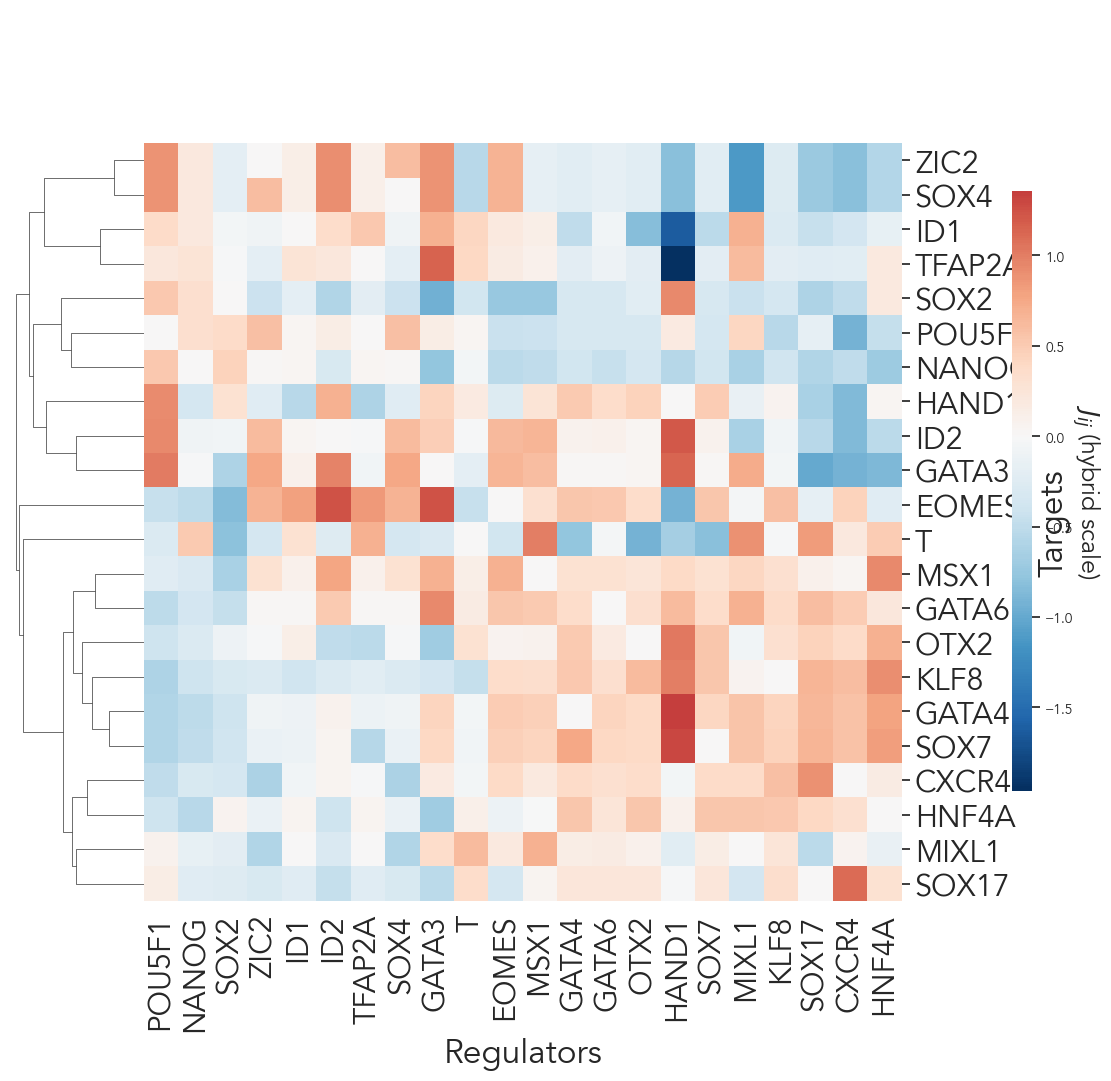

In [66]:
def plot_grouped_heatmap_with_clustering(interaction_matrix, all_genes, sel_genes):
    if isinstance(all_genes, np.ndarray):
        all_genes = list(all_genes)

    ordered_genes = [g for g in sel_genes if g in all_genes]
    gene_indices = [all_genes.index(gene) for gene in ordered_genes]
    filtered_matrix = interaction_matrix[np.ix_(gene_indices, gene_indices)]

    mean_J = np.mean(interaction_matrix)
    std_J = np.std(interaction_matrix)
    transformed_matrix = np.vectorize(custom_transform)(filtered_matrix, mean_J, std_J)

    df = pd.DataFrame(transformed_matrix, index=ordered_genes, columns=ordered_genes)

    # Unica clustermap finale con tutto
    g = sns.clustermap(df, cmap="RdBu_r", figsize=(10, 10),
                       row_cluster=True, col_cluster=False,
                       xticklabels=True, yticklabels=True,
                       center=0,
                       vmin=np.min(transformed_matrix),
                       vmax=np.max(transformed_matrix),
                       cbar_kws={"label": r"$J_{ij}$ (hybrid scale)"},
                       dendrogram_ratio=(.15, .15),  # proporzione per dendrogrammi
                       cbar_pos=(1.02, 0.2, 0.02, 0.6))  # posizione della colorbar

    g.ax_heatmap.set_xlabel("Regulators", fontsize=24)
    g.ax_heatmap.set_ylabel("Targets", fontsize=24)
    g.ax_heatmap.tick_params(axis='x', labelrotation=90, labelsize=22)
    g.ax_heatmap.tick_params(axis='y', labelsize=22)

    g.cax.set_ylabel(r'$J_{ij}$ (hybrid scale)', rotation=270, labelpad=20, fontsize=18)
    g.cax.tick_params(labelsize=10)
    plt.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/GRN_best_inferred_matrix_selected_genes.svg", format="svg")

    plt.show()
    
plot_grouped_heatmap_with_clustering(best_model_nodiag, genes_relevant, genes_list)


Total edges drawn: 7


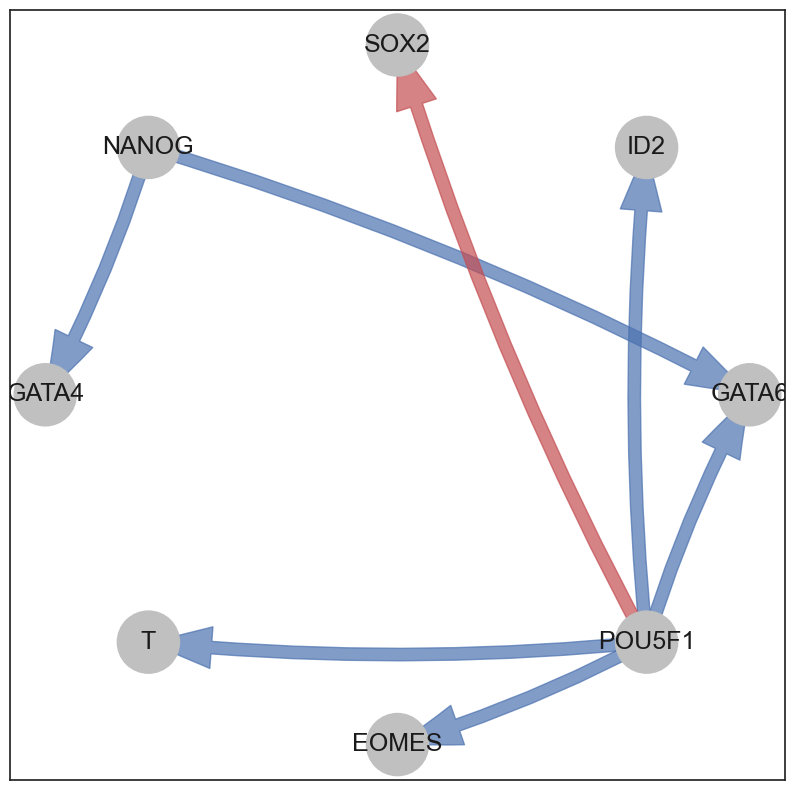

Total edges drawn: 6


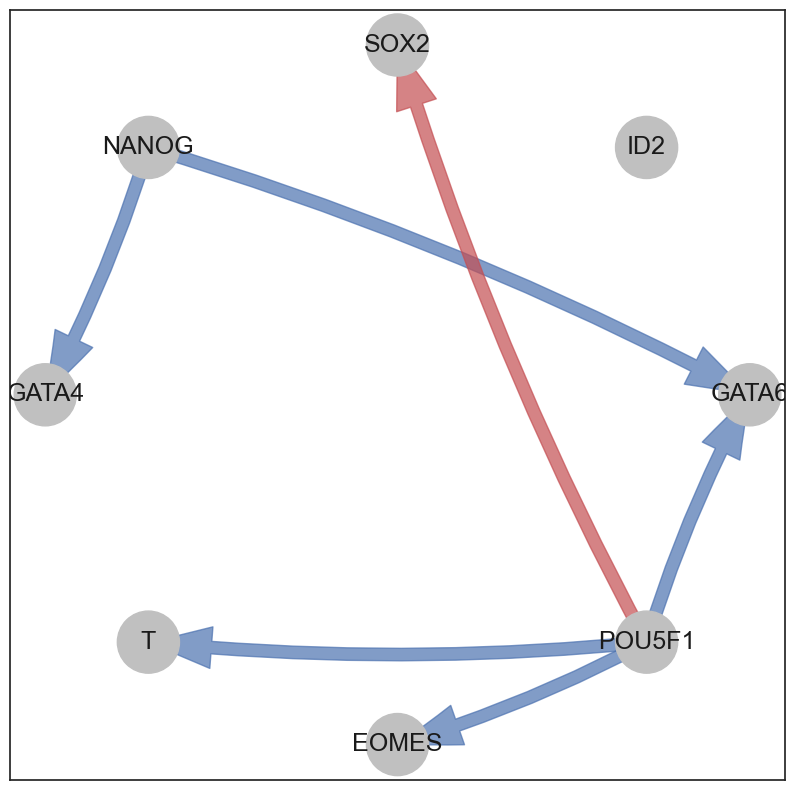

In [67]:
adj_matx = na.to_adj_matrix(best_model_sel, thr = 0.0)
# visualize the adjacency matrix
visualise_adj = False
if visualise_adj:
    plt.figure(figsize=(7,6))
    sns.heatmap(adj_matx, cmap="coolwarm", cbar=False, center=0, linewidth=.5)
    plt.xticks(fontsize=16, rotation=90, labels=genes_relevant, ticks=np.arange(0.5, len(genes_relevant), 1))
    plt.yticks(fontsize=16, rotation=0, labels=genes_relevant[::-1], ticks=np.arange(0.5, len(genes_relevant), 1))


na.visualize_graphTrue(adj_matx, genes_relevant, [], [], [], literature_based_interactions,"")
plt.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/GRN_true_forScode.svg", format="svg")

plt.show()
plt.close()

na.visualize_graphSel(adj_matx, genes_relevant, [], [], [], literature_based_interactions,"")
plt.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/GRN_inferred_forScode.svg", format="svg")

plt.show()
plt.close()




# WT GA generation - Evaluating the results

In [68]:
def compute_distances_and_matrices(model, N_test, spins_df_lN_mb_pst, cm_original_lN, noise_dist, funcs_ko=funcs_ko, n_times = int(1e3)):
    """
    Generate spins and correlation matrices from the given model and compute the distance
    to the original correlation matrix.

    Parameters:
    - model: Model to use for generating samples.
    - N_test: Number of test samples to generate.
    - spins_df_lN_mb_pst: Template for the dimensions of the spin arrays.
    - cm_original_lN: Original correlation matrix to compare against.
    - noise_dist: Noise level for normalizing the distance.
    - funcs_ko: Object containing the distance function.

    Returns:
    - generated_spins: Array of generated spins.
    - generated_cms: Array of generated correlation matrices.
    - dist_val: Computed distance value, normalized by the number of non-NaN matrices and noise level.
    """
    # Generate samples
    # n_times = spins_df_lN_mb_pst.shape[1]
    generated_spins = np.zeros((spins_df_lN_mb_pst.shape[0], n_times,N_test))
    # initial_spins = np.zeros((spins_df_lN_mb_pst.shape[0], N_test))
    # initial_spins_el = np.zeros((spins_df_lN_mb_pst.shape[0], N_test))

    for ll in range(N_test):
        generated_spins[:, :, ll] = model.generate_samples(seed=ll*2, t_size=n_times) #, initial_spins[:,ll], initial_spins_el[:,ll]

    # Compute correlation matrices and distance
    total_dist = 0
    nan_counts = 0
    generated_cms = np.zeros((spins_df_lN_mb_pst.shape[0], spins_df_lN_mb_pst.shape[0], N_test))
    dist_tosave = np.zeros(N_test)
    for ll in range(N_test):
        cm_sim = np.corrcoef(generated_spins[:, :, ll])
        generated_cms[:, :, ll] = cm_sim
        dist = funcs_ko.sum_squared_abs_diff(cm_original_lN, cm_sim)
        if np.isnan(cm_sim).sum() > (generated_spins.shape[0] * generated_spins.shape[0] * 0.3):
            nan_counts += 1
        else:
            total_dist += dist
        dist_tosave[ll] = dist

    # Calculate the final distance value
    if nan_counts >= N_test*0.4:
        dist_val = np.nan
    else:
        dist_val = (total_dist / (N_test - nan_counts)) / noise_dist

    return generated_spins, generated_cms, dist_val, dist_tosave#, initial_spins, initial_spins_el



In [69]:
models_sel = [models[ii] for ii in idxs_sel_CMD]

N_genes = spins_df_lN_mb_pst.shape[0]
N_sim = spins_df_lN_mb_pst_shuffle.shape[0] 
print(f"N_genes: {N_genes}, N_sim: {N_sim}, Ntimes: {Ntimes}")

generated_spins = np.zeros((len(models_sel), N_genes, Ntimes, N_test))

generated_cms = np.zeros((len(models_sel), N_genes, N_genes, N_test))
dist_check = np.zeros(len(models_sel))
dist_not_scaled = np.zeros((len(models_sel), N_test))

for ii, model in enumerate(tqdm(models_sel, desc="Processing models", unit="model")):
    generated_spins[ii,:,:,:], generated_cms[ii,:,:,:], dist_check[ii], dist_not_scaled[ii,:] = compute_distances_and_matrices(
        model,
        N_test,
        spins_df_lN_mb_pst,
        cm_original_lN,
        noise_dist,
        n_times=Ntimes
    )
    
    if dist_check[ii] - cmd_sel[ii] > 1e-3:
        print("Warning: distance values do not match")

N_genes: 98, N_sim: 150, Ntimes: 709


Processing models:   0%|          | 0/10 [00:00<?, ?model/s]/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
Processing models: 100%|██████████| 10/10 [01:36<00:00,  9.61s/model]


## Initial spins inspection

In [70]:
# N_genes = spins_df_lN_mb_pst.shape[0]
# generated_spins_init = np.zeros((N_rnd_search, N_genes,1, N_test))

# for ii, model in enumerate(tqdm(models, desc="Processing models", unit="model")):
#     generated_spins_init[ii,:,:,:], _, _, _ = compute_distances_and_matrices(
#         model,
#         N_test,
#         spins_df_lN_mb_pst,
#         cm_original_lN,
#         noise_dist,
#         n_times=1
#     )


In [71]:
# initial_spins_el = generated_spins_init[:, :, 0, :].copy()  # Shape: (250, 98, 150)
# data = initial_spins_el.transpose(0, 2, 1).reshape(250 * 150, -1)

# # Step 2: Repeat CMD values for each model (150 times per model)
# cmd_expanded = np.repeat(cmd_sel[:250], 150)  # Shape: (250*150,)

# # Step 3: Filter out NaNs from CMD and corresponding data
# valid_indices = ~np.isnan(cmd_expanded)
# filtered_data = data[valid_indices, :]
# filtered_colors = cmd_expanded[valid_indices]

# # Step 4: Sanity checks
# print(f"Original data shape: {data.shape}")
# print(f"Filtered data shape: {filtered_data.shape}")
# print(f"Original CMD shape: {cmd_expanded.shape}")
# print(f"Filtered CMD shape: {filtered_colors.shape}")

# # Step 5: PCA
# pca = PCA(n_components=2)
# pca_result = pca.fit_transform(filtered_data)

# # Step 6: PCA plot with CMD colors
# plt.figure(figsize=(5, 4))
# scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=filtered_colors, cmap="viridis", s=5, alpha=0.7)
# cbar = plt.colorbar(scatter)
# cbar.set_label("CMD Value (Normalized)")

# plt.xlabel("Principal Component 1")
# plt.ylabel("Principal Component 2")
# plt.title("PCA of Gene Expression Data (150 datasets per Model)")
# plt.show()

In [72]:
# cmd_expanded = np.repeat(cmd_sel[:250], 150)  

# filtered_cmd = cmd_expanded[valid_indices]  

# corr_pc1, p_pc1 = stats.pearsonr(filtered_cmd, pca_result[:, 0])
# corr_pc2, p_pc2 = stats.pearsonr(filtered_cmd, pca_result[:, 1])

# print(f"Correlation CMD - PC1: {corr_pc1:.2f} (p-value: {p_pc1:.3f})")
# print(f"Correlation CMD - PC2: {corr_pc2:.2f} (p-value: {p_pc2:.3f})")

## CMD between GA generated and input

In [73]:
# noise_dist = np.mean([funcs_ko.sum_squared_abs_diff(cm_original_lN, corr_matxs_rnd_lN[i,:,:]) for i in range(N_test)])
rnd_dists = np.array([funcs_ko.sum_squared_abs_diff(cm_original_lN, corr_matxs_rnd_lN[i,:,:]) for i in range(N_test)])
print(rnd_dists.shape)

dist = dist_not_scaled[0,:]
t_stat, p_value = stats.ttest_ind(dist, rnd_dists)
print("Statistiche t:", t_stat)
print("P-value:", p_value)

t_stat_welch, p_value_welch = stats.ttest_ind(dist, rnd_dists, equal_var=False)

print("Statistiche t (Welch):", t_stat_welch)
print("P-value (Welch):", p_value_welch)

(150,)
Statistiche t: -66.00789368489548
P-value: 6.551497078631541e-180
Statistiche t (Welch): -66.00789368489549
P-value (Welch): 3.19625822957788e-112


In [74]:
class MidpointNormalize(pltcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        pltcolors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return np.ma.masked_array(np.interp(value, x, y), np.isnan(value))


def plotcm(m, fig, ax, ax_names, text, fix = False, cmap = 'RdBu_r'):
    plt.rcParams['font.family'] = 'Avenir'
    plt.rcParams['text.usetex'] = False
    # Crea un oggetto FontProperties per Avenir
    avenir_font = FontProperties(family='Avenir', size=16)

    # Imposta i font degli xticks
    for label in ax.get_xticklabels():
        label.set_fontproperties(avenir_font)

    # Imposta i font degli yticks
    for label in ax.get_yticklabels():
        label.set_fontproperties(avenir_font)
    matplotlib.rc('text', usetex=True)
    sns.set(font='Avenir')
    sns.set(style="white")
    if fix == True:
        img = ax.imshow(m, cmap = cmap, clim=(-1, 1),
                    norm = MidpointNormalize(midpoint=0,
                                             vmin=-1,
                                             vmax=1)
                   )
    else:
        lim_val = max(np.abs(np.nanmin(m)), np.nanmax(m))
        
        img = ax.imshow(m, cmap = cmap, clim=(-lim_val, lim_val),
                        norm = MidpointNormalize(midpoint=0,
                                                vmin = -lim_val,
                                                vmax =  lim_val)
                    )
    
    # cbarM = fig.colorbar(img, ax = ax)
    cbarM = fig.colorbar(img, ax=ax, fraction=0.046, pad=0.02)
    cbarM.set_label(r'$C_{ij}$', rotation = -90, labelpad = 20, fontsize = 7)


    cbarM.ax.tick_params(labelsize = 10)
    cbarM.ax.set_yticklabels(cbarM.ax.get_yticklabels(), fontname='Avenir')

    ax.set_xticks(np.arange(0,np.shape(np.array(m))[0]))
    ax.set_xticklabels(ax_names, rotation='vertical', fontsize=7)
    ax.set_yticks(np.arange(0,np.shape(np.array(m))[0]))
    ax.set_yticklabels(ax_names, fontsize=7)
    fig.suptitle(text, fontsize=12)



In [75]:
generated_cms.shape



(10, 98, 98, 150)

/var/folders/2z/hsgwjl3d49109llzgvkyf6jw0000gn/T/ipykernel_27081/702083812.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbarM.ax.set_yticklabels(cbarM.ax.get_yticklabels(), fontname='Avenir')


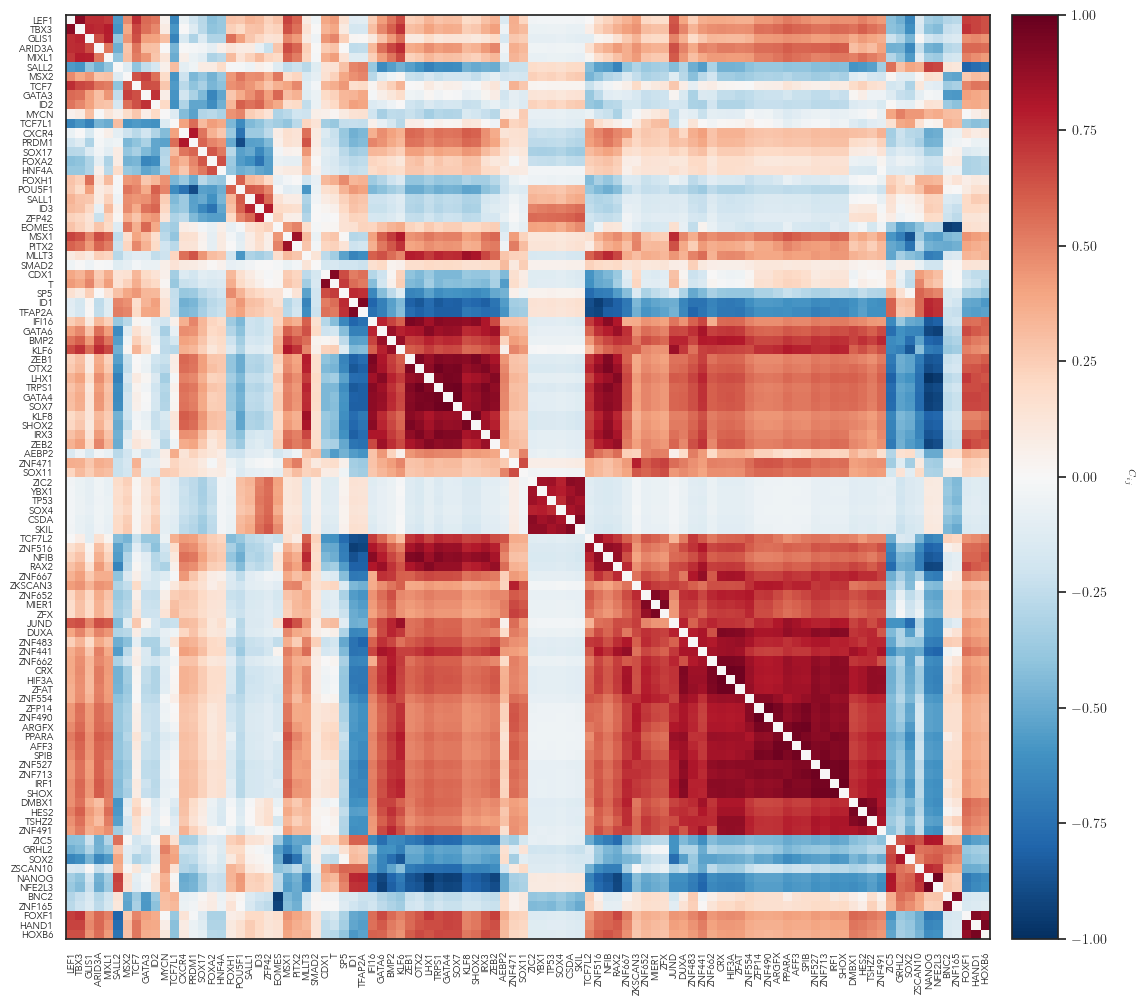

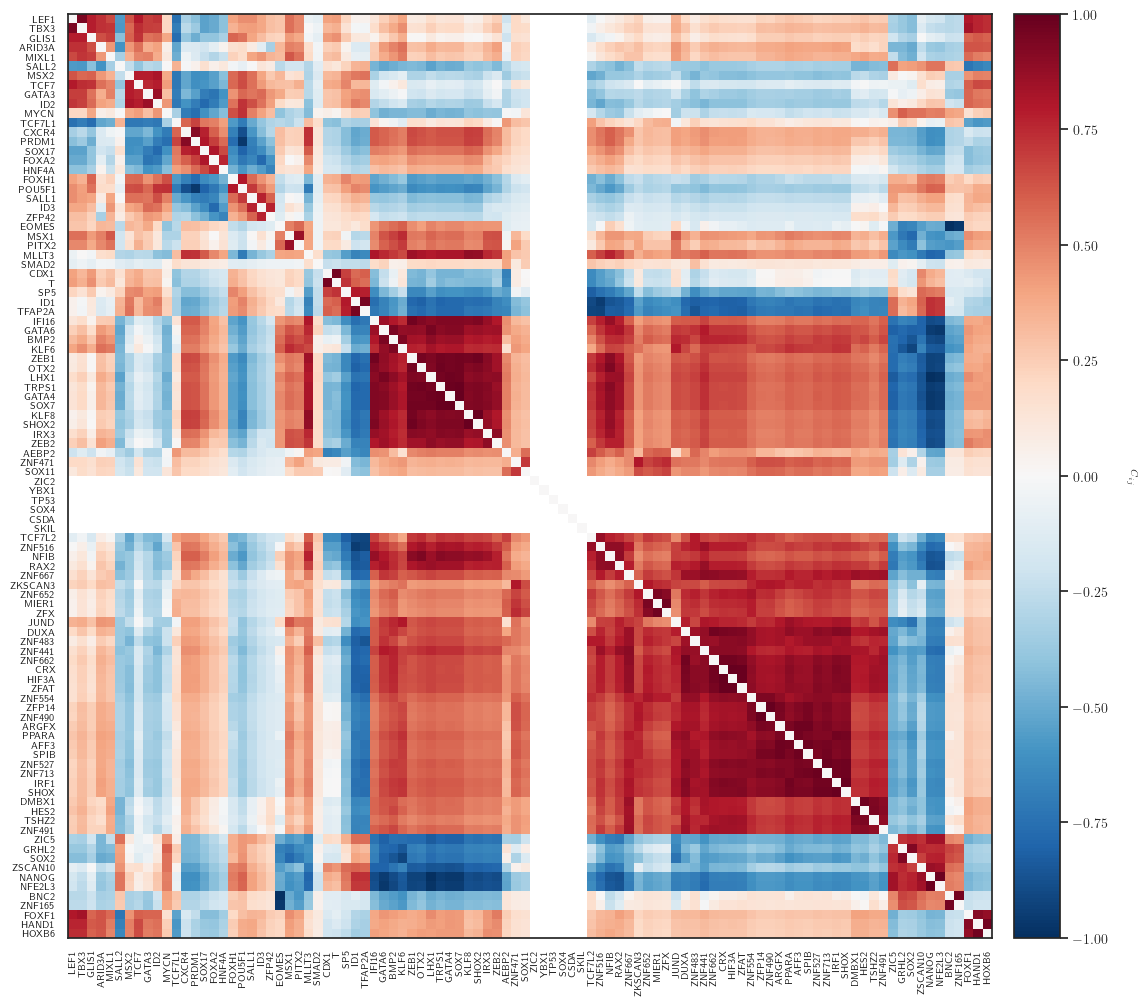

In [76]:
# Visualize the simulated correlation matrices
cm_sim_lN_mean = np.nanmean(generated_cms[0,:,:,:], axis=2)

# Riordina righe e colonne di `cm_sim_lN_mean` e `cm_original_lN` usando `col_order`
cm_sim_lN_mean_reordered = cm_sim_lN_mean[np.ix_(col_order, col_order)]
cm_original_lN_reordered = cm_original_lN[np.ix_(col_order, col_order)]
genes_relevant_reordered = genes_relevant[col_order]

# remove diagonal
np.fill_diagonal(cm_sim_lN_mean_reordered, 0)
np.fill_diagonal(cm_original_lN_reordered, 0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 12))
plotcm(cm_sim_lN_mean_reordered, fig, ax, genes_relevant_reordered, "", fix = True)
fig.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/cm_simulated.svg", format="svg")
plt.show()

# Visualize the Original correlation matrices
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 12))
plotcm(cm_original_lN_reordered, fig, ax, genes_relevant_reordered, "", fix = True)
fig.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/cm_original.svg", format="svg")
plt.show()  



# Clustering WT GA


In [77]:
model_n = 0

### Clustering WT GA generated - subsample


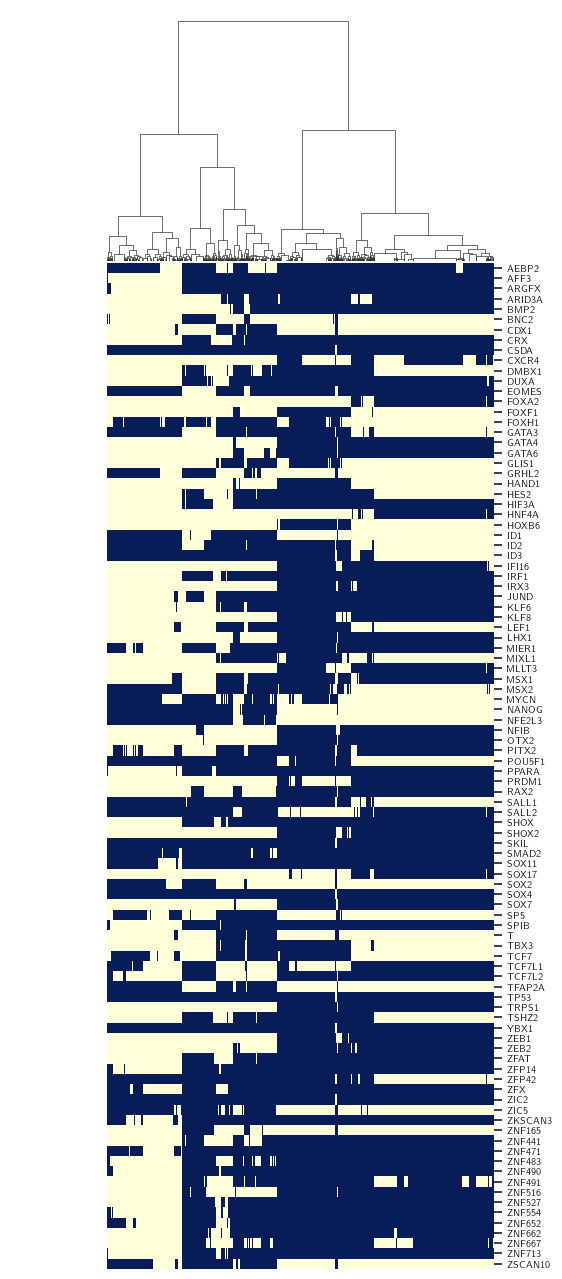

In [78]:
# Clustering
# simulated_KO_ga
n_selected_dfs = 10
np.random.seed(101010)
rnd_indices = np.random.choice(np.arange(0, N_test), n_selected_dfs, replace=False)
generated_spins_merged = np.concatenate([generated_spins[model_n, :, :, ii] for ii in rnd_indices], axis=1)
col_linkage_sim = scipy.cluster.hierarchy.linkage(generated_spins_merged.T, method='ward') # For single dataset use: generated_spins[model_n,:,:, jj]

g = sns.clustermap(generated_spins_merged,col_linkage=col_linkage_sim, cmap='YlGnBu',
                   yticklabels=genes_relevant, cbar_pos=None,  
                   figsize=(6, 13), row_cluster=False, col_cluster=True, xticklabels=False)

g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
plt.show()


## PCA input

In [79]:
# PCA of input WT GA
pca_wt_input = PCA(n_components=2)
pca_wt_input.fit(spins_df_lN_mb_pst.T)
input_wt_transformed = pca_wt_input.transform(spins_df_lN_mb_pst.T)
principalDf_input = pd.DataFrame(data=input_wt_transformed, columns=['PC1', 'PC2'])


### PCA input GA by PST

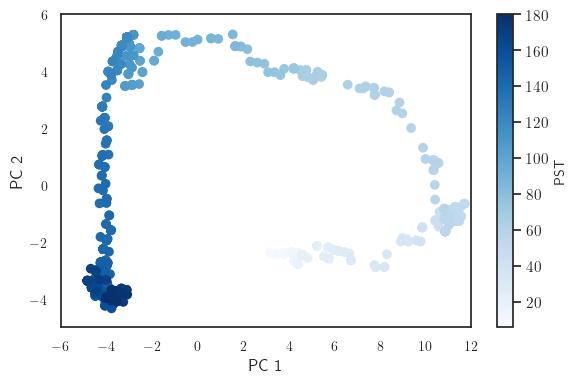

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))  

# Plot per Input WT
scatter = ax.scatter(principalDf_input['PC1'], principalDf_input['PC2'], c=pst_mb_avg, cmap="Blues")
cb_input = fig.colorbar(scatter, ax=ax)  
cb_input.set_label("PST", fontsize=10) 

ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_xlim(-6, 12)
ax.set_ylim(-5,6)

plt.tight_layout()
plt.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS8/GA_in_PCA_with_PST.svg", format="svg")
plt.show()

### PCA input data by clustering on GE

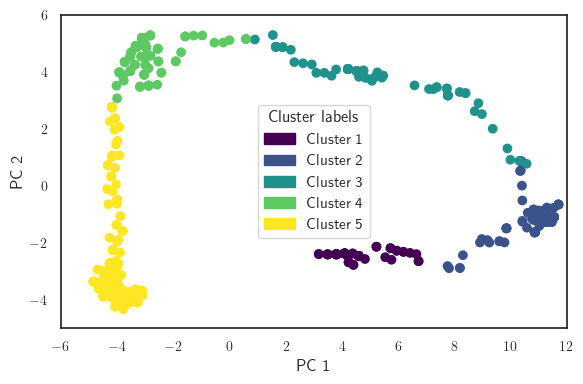

In [81]:
pca_wt_input = PCA(n_components=2)
pca_wt_input.fit(spins_df_lN_mb_pst.T)
input_wt_transformed = pca_wt_input.transform(spins_df_lN_mb_pst.T)
principalDf_input = pd.DataFrame(data=input_wt_transformed, columns=['PC1', 'PC2'])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))  
colors = plt.cm.viridis(np.linspace(0, 1, 5))
cmap_cluster = ListedColormap(colors)
scatter = ax.scatter(principalDf_input['PC1'], principalDf_input['PC2'], c=cl_labels_avg, cmap=cmap_cluster)
legend_handles = [mpatches.Patch(color=cmap_cluster(i), label=f'Cluster {i+1}') for i in range(5)]
ax.legend(handles=legend_handles, title="Cluster labels")


ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_xlim(-6, 12)
ax.set_ylim(-5,6)

plt.tight_layout()
plt.show()

#### Clusters area from INPUT GA

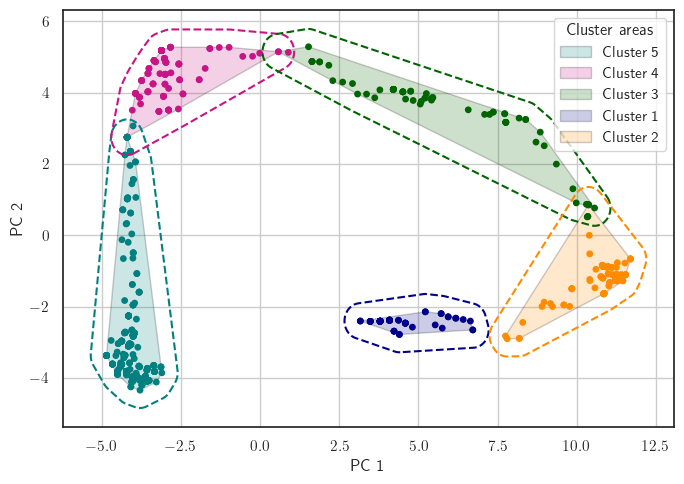

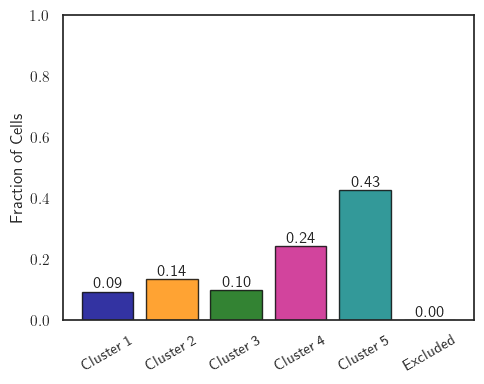

In [136]:
# Define colors for clusters
cluster_colors = {
    1: 'darkblue',
    2: 'darkorange',
    3: 'darkgreen',
    4: 'mediumvioletred',
    5: 'teal',
    # 6: 'firebrick',
}
excluded_color = 'lightgray'
priority_order = [5,  4, 3, 1, 2]  # Cluster priority

# Compute cluster polygons
cluster_polygons = {}
alpha = 10
for cluster_id in np.unique(cl_labels_avg):
    cluster_points = principalDf_input[cl_labels_avg == cluster_id][['PC1', 'PC2']].values
    _, poly = cl_funcs.alpha_shape(cluster_points, alpha)
    if not poly.is_empty:
        cluster_polygons[cluster_id] = poly

# Compute buffers
buffer_size = 0.5
buffered_polygons = {cluster_id: poly.buffer(buffer_size) for cluster_id, poly in cluster_polygons.items()}

# Calculate points and plot results
points_count, point_colors = cl_funcs.calculate_points_in_clusters(principalDf_input, buffered_polygons, cluster_colors, priority_order)
cl_funcs.plot_pca_space(principalDf_input, cluster_polygons, buffered_polygons, cluster_colors, priority_order, point_colors)


frac_wt_ga_input, fig_hist = cl_funcs.plot_histogram(points_count, cluster_colors, excluded_color, frac=True)

fig_hist.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/histogram_frac_ga_input.svg", format="svg")
plt.show()


In [128]:
def plot_pca_space_with_density(data, buffered_polygons, cluster_colors, priority_order, 
                                x_bins=100, y_bins=100, threshold=0.005, cmap="Oranges", 
                                scientific_notation=True, log_scale_ticks=False):
    """
    Plots the PCA space with:

    - Cluster buffer contours (dashed lines).
    - Cell density as a 2D histogram with thresholding.
    - Customizable colorbar formatting (scientific notation, log-scale ticks).

    Parameters:
    - data: DataFrame with "PC1" and "PC2" columns.
    - buffered_polygons: dict {cluster_id: buffered shapely polygon}.
    - cluster_colors: dict {cluster_id: color}.
    - priority_order: list of cluster IDs (drawn in order).
    - x_bins, y_bins: number of bins for the 2D histogram.
    - threshold: density threshold (as fraction of max) to filter low-density regions.
    - cmap: colormap for the density plot.
    - scientific_notation: if True, format colorbar ticks in scientific notation.
    - log_scale_ticks: if True, show only powers of 10 on the colorbar.
    """

    fig, ax = plt.subplots(figsize=(7.5, 5))

    # **1. Plot dei contorni dei buffer dei cluster**
    for cluster_id in priority_order:
        if cluster_id in buffered_polygons:
            color = cluster_colors.get(cluster_id, "black")  
            buffered_poly = buffered_polygons[cluster_id]

            # Disegna il buffer con linea tratteggiata
            if buffered_poly.geom_type == "MultiPolygon":
                for sub_poly in buffered_poly.geoms:
                    x_poly, y_poly = sub_poly.exterior.xy
                    ax.plot(x_poly, y_poly, color=color, lw=1.5, linestyle="--", alpha=0.8)
            else:
                x_poly, y_poly = buffered_poly.exterior.xy
                ax.plot(x_poly, y_poly, color=color, lw=1.5, linestyle="--", alpha=0.8)

    # **2. Calcola la densità con un istogramma 2D**
    counts, xedges, yedges = np.histogram2d(
        data["PC1"], data["PC2"], bins=[x_bins, y_bins]
    )

    # Applica la soglia per eliminare le regioni a bassa densità
    thr = counts.max() * threshold
    counts[counts < thr] = 0  

    # **3. Plotta l'istogramma 2D**
    pcm = ax.pcolormesh(xedges, yedges, counts.T, cmap=cmap, norm=LogNorm(), shading='auto')
    cbar = plt.colorbar(pcm, ax=ax)
    cbar.set_label("Density", fontsize=23)

    # **Aumenta il numero di ticks nella colorbar**
    cbar.ax.tick_params(labelsize=20)

    # **Imposta i ticks della colorbar**
    if np.any(counts > 0):  
        if log_scale_ticks:
            cbar_ticks = 10 ** np.arange(
                np.floor(np.log10(counts[counts > 0].min())), 
                np.ceil(np.log10(counts.max())) 
            )  # Solo potenze di 10
        else:
            cbar_ticks = np.linspace(counts[counts > 0].min(), counts.max(), num=4)  

        cbar.set_ticks(cbar_ticks)

        if scientific_notation:
            cbar.set_ticklabels([f"{t:.0e}" for t in cbar_ticks])  # Notazione scientifica (es: 1e3)
        else:
            cbar.set_ticklabels([f"{int(t)}" for t in cbar_ticks])  # Numeri interi

    # **Formattazione del grafico**
    ax.set_xlabel("PC1", fontsize=23)
    ax.set_ylabel("PC2", fontsize=23)
    ax.tick_params(axis="both", labelsize=20)  
    plt.tight_layout()
    plt.xlim(-6, 14)
    plt.ylim(-5.5, 6.5)
    plt.grid()
    return(fig)



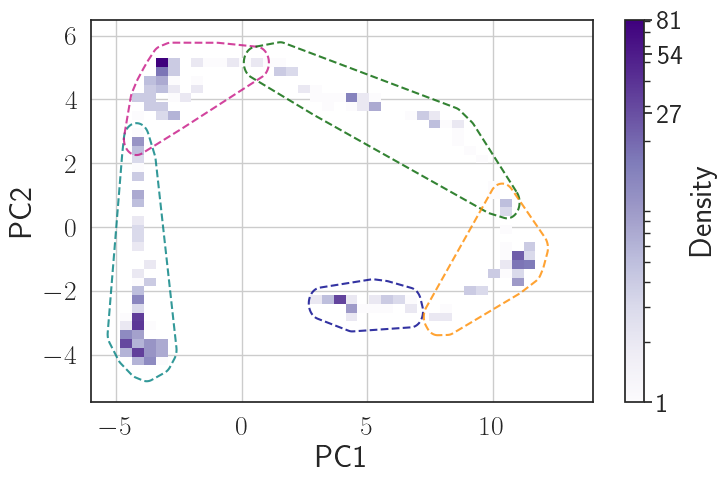

In [129]:

x_bins = np.linspace(principalDf_input['PC1'].min(), principalDf_input['PC1'].max(), 36)
y_bins = np.linspace(principalDf_input['PC2'].min(), principalDf_input['PC2'].max(), 36)
    
fig_pca_input = plot_pca_space_with_density(principalDf_input, buffered_polygons, cluster_colors, priority_order, 
                            x_bins=x_bins, y_bins=y_bins, threshold=0.005, cmap="Purples", scientific_notation=False, log_scale_ticks= False)
fig_pca_input.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/pca_ga_input.svg", format="svg")
plt.show()


In [130]:
counts_tot = np.array(np.unique(cl_labels_avg, return_counts=True))[1]
freq = counts_tot / np.sum(counts_tot)
freq

array([0.09449929, 0.14527504, 0.09449929, 0.24823695, 0.41748942])

#### Cluster analysis for generated WT GA


/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


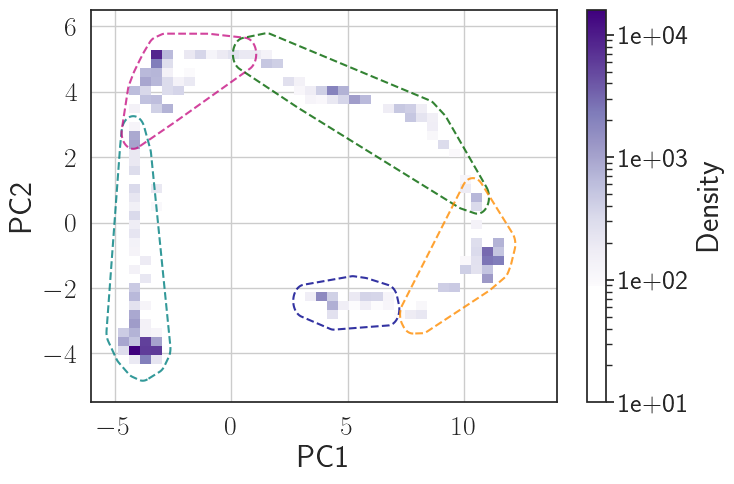

In [131]:
cluster_colors = {
    1: 'darkblue',
    2: 'darkorange',
    3: 'darkgreen',
    4: 'mediumvioletred',
    5: 'teal',
    # 6: 'firebrick',
}

# PCA simulated WT GA
generated_spins_merged = np.concatenate([generated_spins[model_n, :, :, ii] for ii in range(generated_spins.shape[3])], axis=1)
wt_transformed = pca_wt_input.transform(generated_spins_merged.T)
principalDf_wt_ga = pd.DataFrame(data=wt_transformed, columns=['PC1', 'PC2'])

# # Calculate points and assign colors for the new dataset
# points_count_wt_ga, point_colors_wt_ga = cl_funcs.calculate_points_in_clusters(
#     principalDf_wt_ga, buffered_polygons, cluster_colors, priority_order
# )

# frac_wt_ga_gen = cl_funcs.plot_histogram(points_count_wt_ga, cluster_colors, excluded_color, frac=True)

fig_pca_generated = plot_pca_space_with_density(principalDf_wt_ga, buffered_polygons, cluster_colors, priority_order, 
                            x_bins=x_bins, y_bins=y_bins, threshold=0.005, cmap="Purples", scientific_notation=True, log_scale_ticks= True)
fig_pca_generated.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/pca_ga_wt_generated.svg", format="svg")
plt.show()


In [132]:
# Function to process a batch
def process_batch(generated_spins, batch_idx, batch_size = 1, model_n=0):
    start_idx = batch_idx * batch_size
    end_idx = start_idx + batch_size
    
    batch_data = np.concatenate([generated_spins[model_n, :, :, ii] for ii in range(start_idx, end_idx)], axis=1)
    
    # Perform PCA
    wt_transformed = pca_wt_input.transform(batch_data.T)
    principalDf_wt_ga = pd.DataFrame(data=wt_transformed, columns=['PC1', 'PC2'])

    # Compute points count for this batch
    points_count, _ = cl_funcs.calculate_points_in_clusters(principalDf_wt_ga, buffered_polygons, cluster_colors, priority_order)
    
    # Convert counts to fractions
    total_points = sum(points_count.values())  
    if total_points > 0:
        points_count = {k: v / total_points for k, v in points_count.items()} 

    return points_count  


In [133]:
def compute_mean_sem(cluster_fractions):
    """
    Compute the mean and standard error of the mean (SEM) for each cluster.

    Parameters:
    - cluster_fractions: Dictionary where keys are cluster IDs and values are lists of fractions across batches.

    Returns:
    - cluster_means: Dictionary with the mean fraction for each cluster.
    - cluster_sems: Dictionary with the SEM for each cluster.
    """
    cluster_means = {cluster_id: np.mean(values) for cluster_id, values in cluster_fractions.items()}
    cluster_sems = {cluster_id: np.std(values, ddof=1) / np.sqrt(len(values)) for cluster_id, values in cluster_fractions.items()}
    return cluster_means, cluster_sems


def plot_cluster_fractions(cluster_means, cluster_sems, cluster_colors):
    """
    Plot a bar chart with mean fraction and SEM for each cluster.

    Parameters:
    - cluster_means: Dictionary with the mean fraction for each cluster.
    - cluster_sems: Dictionary with the SEM for each cluster.
    - cluster_colors: Dictionary mapping cluster IDs to colors.
    """
    # Sort cluster IDs for consistent ordering
    sorted_clusters = sorted(cluster_means.keys(), key=lambda x: (x == 'Excluded', x))

    # Prepare data for plotting
    means = [cluster_means[c] for c in sorted_clusters]
    sems = [cluster_sems[c] for c in sorted_clusters]
    labels = [f'Cluster {c}' if c != 'Excluded' else 'Excluded' for c in sorted_clusters]
    colors = [cluster_colors.get(c, "lightgray") for c in sorted_clusters]

    # Create the error bar plot
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(labels, means, yerr=sems, capsize=5, color=colors, alpha=0.8, edgecolor='black')

    # Label bars with mean values
    for i, (mean, sem) in enumerate(zip(means, sems)):
        ax.text(i, mean + sem + 0.005, f"{mean:.2f}", ha='center', fontsize=12)
        
    # y axis lim in 0-1
    ax.set_ylim(0, 1)

    # Formatting
    ax.set_ylabel("Fraction of Cells")
    plt.xticks(rotation=30)
    plt.tight_layout()

    # Show plot
    # plt.show()
    return(fig)
  

In [134]:
# Define batch size
batch_size = 1
num_batches = generated_spins.shape[3] // batch_size

# Run batches in parallel
results = Parallel(n_jobs=-1)(delayed(process_batch)(generated_spins, batch_idx) for batch_idx in range(num_batches))

# Aggregate results
cluster_fractions = {cluster_id: [] for cluster_id in cluster_colors.keys()}
cluster_fractions['Excluded'] = []  # Include unassigned points

# Saving fractions for each cluster
for points_fraction in results:
    for cluster_id, fraction in points_fraction.items():
        cluster_fractions[cluster_id].append(fraction)
  
# Compute mean and SEM for each cluster
cluster_means, cluster_sems = compute_mean_sem(cluster_fractions)



/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted w

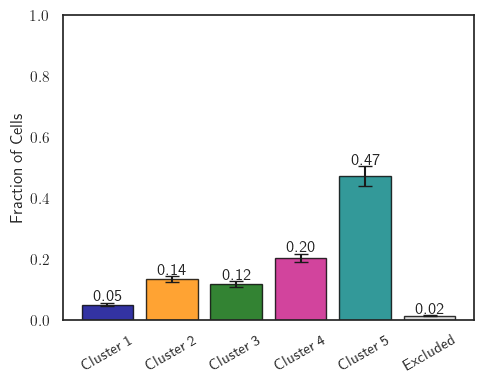

In [135]:
# Plot the results
fig_hist_generated = plot_cluster_fractions(cluster_means, cluster_sems, cluster_colors)
fig_hist_generated.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/histogram_frac_ga_generated.svg", format="svg")
plt.show()

In [91]:
cluster_means

{1: 0.05159379407616361,
 2: 0.13507287259050305,
 3: 0.11965209214856605,
 4: 0.2042031029619182,
 5: 0.4734085566525623,
 'Excluded': 0.016069581570286786}

#### Cluster analysis for generated WT GA - Models comparison


In [123]:
# Run batches in parallel
results_all_models = []
frac_mean_all_model = []
frac_sem_all_model = []

for model in range(generated_spins.shape[0]):
    results_per_model = Parallel(n_jobs=-1)(delayed(process_batch)(generated_spins, batch_idx, model_n = model) for batch_idx in range(num_batches))
    results_all_models.append(results_per_model)
    
    cluster_fractions_per_model = {cluster_id: [] for cluster_id in cluster_colors.keys()}
    cluster_fractions_per_model['Excluded'] = []  # Include unassigned points

    # Saving fractions for each cluster
    for points_fraction in results_all_models[model]:
        for cluster_id, fraction in points_fraction.items():
            cluster_fractions_per_model[cluster_id].append(fraction)
    
    # Compute mean and SEM for each cluster
    cluster_means_per_model, cluster_sems_per_model = compute_mean_sem(cluster_fractions_per_model)
    frac_mean_all_model.append(cluster_means_per_model)
    frac_sem_all_model.append(cluster_sems_per_model)

    


/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted w

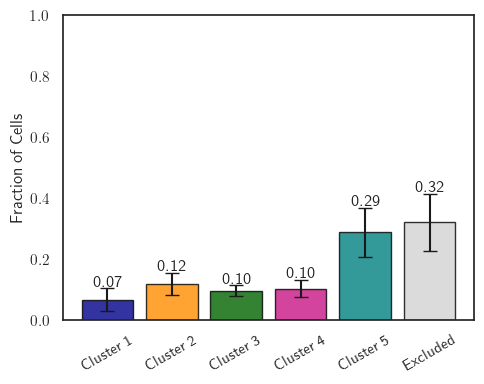

In [124]:

from collections import defaultdict

all_means_by_cluster = defaultdict(list)

for model_means in frac_mean_all_model:
    for cluster_id, value in model_means.items():
        all_means_by_cluster[cluster_id].append(value)

# mean and SEM across models
mean_across_models = {k: np.mean(v) for k, v in all_means_by_cluster.items()}
sem_across_models = {k: np.std(v, ddof=1) / np.sqrt(len(v)) for k, v in all_means_by_cluster.items()}

fig_hist_generated_10models = plot_cluster_fractions(mean_across_models, sem_across_models, cluster_colors)
fig_hist_generated_10models.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/histogram_frac_ga_generated_10models.svg", format="svg")

In [91]:
# for cluster_id in mean_across_models.keys():
#     values = all_means_by_cluster[cluster_id]
#     print(f"{cluster_id}: mean = {np.mean(values):.3f}, std = {np.std(values, ddof=1):.3f}, sem = {sem_across_models[cluster_id]:.3f}")

## Fraction of Genes Active in each cluster for WT GENERATED GA
https://pmc.ncbi.nlm.nih.gov/articles/PMC4989499/figure/Fig4/

In [92]:
def calculate_cluster_counts(data, gene_index, buffered_polygons, cluster_colors, cluster_order, principalDf):
    """ Calculate the number of active and inactive cells for a given gene in each cluster."""
    active_indices = data[gene_index, :] == 1
    inactive_indices = data[gene_index, :] == -1

    # Compute the number of active and inactive cells in each cluster
    active_principalDf = principalDf[active_indices]
    inactive_principalDf = principalDf[inactive_indices]

    active_cluster_counts, _ = cl_funcs.calculate_points_in_clusters(active_principalDf, buffered_polygons, cluster_colors, cluster_order)
    inactive_cluster_counts, _ = cl_funcs.calculate_points_in_clusters(inactive_principalDf, buffered_polygons, cluster_colors, cluster_order)

    # Reorder the counts based on the cluster order
    active_counts_np = np.array([active_cluster_counts.get(cluster, 0) for cluster in cluster_order])
    inactive_counts_np = np.array([inactive_cluster_counts.get(cluster, 0) for cluster in cluster_order])

    return active_counts_np, inactive_counts_np


In [93]:
sorted_clusters = np.sort(np.unique(cl_labels_avg))

num_clusters=len(sorted_clusters)

sorted_clusters

array([1., 2., 3., 4., 5.])

In [94]:
cluster_order = list(range(1, 6)) #+ ['Excluded'] 

gene1 = "CXCR4"
idx_gene1 = np.where(genes_relevant == gene1)[0][0]
active_counts_1_wt, inactive_counts_1_wt = calculate_cluster_counts(generated_spins_merged, idx_gene1, buffered_polygons, cluster_colors, cluster_order, principalDf_wt_ga)

gene2 = "T"
idx_gene2 = np.where(genes_relevant == gene2)[0][0]
active_counts_2_wt, inactive_counts_2_wt = calculate_cluster_counts(generated_spins_merged, idx_gene2, buffered_polygons, cluster_colors, cluster_order, principalDf_wt_ga)

gene3 = "KLF8"
idx_gene3 = np.where(genes_relevant == gene3)[0][0]
active_counts_3_wt, inactive_counts_3_wt = calculate_cluster_counts(generated_spins_merged, idx_gene3, buffered_polygons, cluster_colors, cluster_order, principalDf_wt_ga)


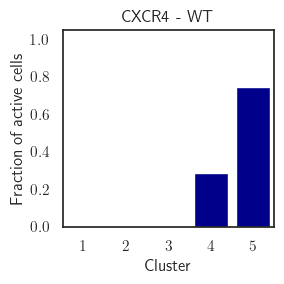

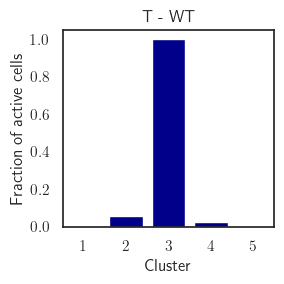

In [95]:

total_cells = (active_counts_3_wt+inactive_counts_3_wt)
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.bar(cluster_order, active_counts_1_wt/total_cells, color='darkblue') #/np.sum(active_counts_1_wt+inactive_counts_1_wt)
ax.set_title(f"{gene1} - WT")
ax.set_xlabel("Cluster")
ax.set_ylabel("Fraction of active cells")
ax.set_xlim(0.5, num_clusters+0.5)
ax.set_ylim(0, 1.05)
ax.set_xticks(cluster_order)
plt.tight_layout()
fig.savefig(f"/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS9/active_cells/WT_active_CXCR4_cells.svg", format="svg")

plt.show()


fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.bar(cluster_order, active_counts_2_wt/total_cells, color='darkblue') # /np.sum(active_counts_2_wt+inactive_counts_2_wt)
ax.set_title(f"{gene2} - WT")
ax.set_xlabel("Cluster")
ax.set_ylabel("Fraction of active cells")
ax.set_xlim(0.5, num_clusters+0.5)
ax.set_ylim(0, 1.05)
ax.set_xticks(cluster_order)
plt.tight_layout()
fig.savefig(f"/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/FigS9/active_cells/WT_active_T_cells.svg", format="svg")

plt.show()




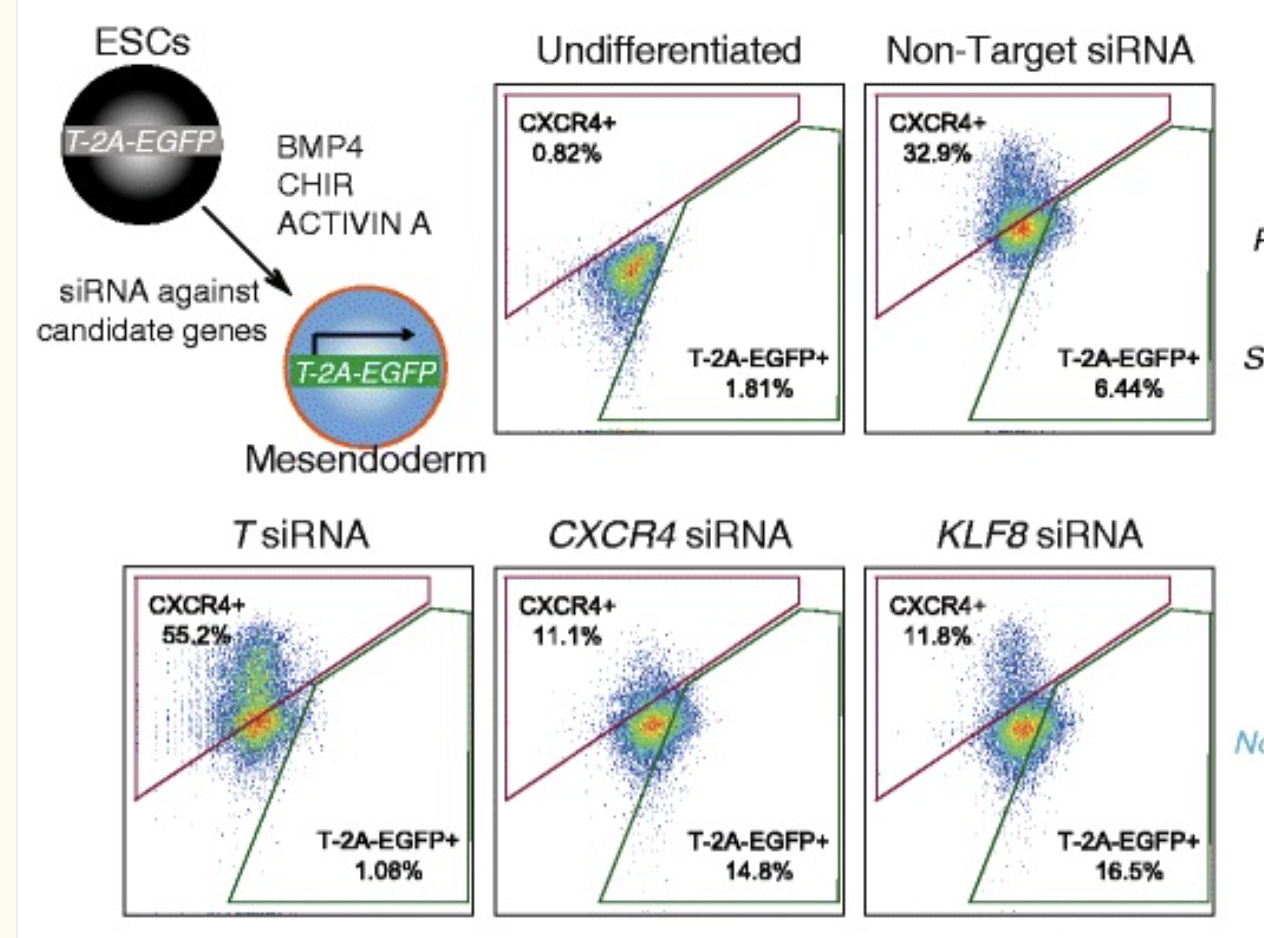

### DIFFERENTIATION SCORE for WT GENERATED GA

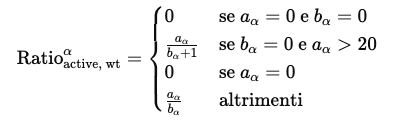

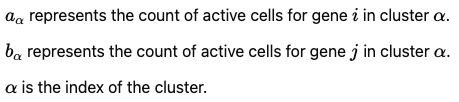

In [96]:
# Computing the differentiation ratio
num_clusters = len(sorted_clusters)  # numero di cluster
differentiation_ratio_wt = np.zeros(num_clusters)

for cluster_idx in range(num_clusters):
    active_gene1 = active_counts_1_wt[cluster_idx]
    active_gene2 = active_counts_2_wt[cluster_idx]

    if active_gene1 == 0 and active_gene2 == 0:
        differentiation_ratio_wt[cluster_idx] = 0
    elif active_gene2 == 0 and active_gene1 > 20:
        differentiation_ratio_wt[cluster_idx] = active_gene1 / (active_gene2 )
    elif active_gene1 == 0:
        differentiation_ratio_wt[cluster_idx] = 0
    else:
        differentiation_ratio_wt[cluster_idx] = active_gene1 / active_gene2




In [97]:
# at relevant time 
active_wt_critical_1 = active_counts_1_wt[3]
inactive_wt_critical_1 = inactive_counts_1_wt[3]
print(f"Active cells in critical clusters for {gene1}:", active_wt_critical_1/(active_wt_critical_1+inactive_wt_critical_1))
active_wt_critical_2 = active_counts_2_wt[3]
inactive_wt_critical_2 = inactive_counts_2_wt[3]
print(f"Active cells in critical clusters for {gene2}:", active_wt_critical_2/(active_wt_critical_2+inactive_wt_critical_2))

reference_ratio_active_wt = active_wt_critical_1 / active_wt_critical_2
print("reference ratio at WT for active GA in generated wt", reference_ratio_active_wt)


Active cells in critical clusters for CXCR4: 0.2865180603874071
Active cells in critical clusters for T: 0.026199372933041275
reference ratio at WT for active GA in generated wt 10.936065573770492


# Importing cluster markers

In [98]:
# CSV
markers_cl = pd.read_csv(path + "/input_data/marker_genes/by_cluster/markers_per_cluster_wilcox.csv")
# Rename the columns of the DataFrame to get the right order
markers_cl.columns = ['cl_1', 'cl_2', 'cl_3', 'cl_4', 'cl_5', 'cl_6']

display(markers_cl.head())


,cl_1,cl_2,cl_3,cl_4,cl_5,cl_6
0,GRHL2,ID1,CDX1,HAND1,EOMES,SHOX2
1,SOX4,EOMES,BMP2,LHX1,LHX1,LHX1
2,SOX2,SOX2,ID1,SHOX2,RAX2,ARID3A
3,SHOX,POU5F1,T,FOXF1,IRF1,GATA6
4,TCF7L1,NANOG,ZSCAN10,GATA6,SHOX,PRDM1


In [99]:
# merge cluster markers: column 5 and 6 removing duplicates
markers_cl["cl_5"] = pd.concat([markers_cl["cl_5"], markers_cl["cl_6"]]).drop_duplicates().reset_index(drop=True)
markers_cl.drop(columns=["cl_6"], inplace=True)

display(markers_cl.head())


,cl_1,cl_2,cl_3,cl_4,cl_5
0,GRHL2,ID1,CDX1,HAND1,EOMES
1,SOX4,EOMES,BMP2,LHX1,LHX1
2,SOX2,SOX2,ID1,SHOX2,RAX2
3,SHOX,POU5F1,T,FOXF1,IRF1
4,TCF7L1,NANOG,ZSCAN10,GATA6,SHOX


In [100]:
cluster_markers = {col: markers_cl[col].dropna() for col in markers_cl.columns} # NOT sorted genes alphabetically

cluster_markers.keys()


dict_keys(['cl_1', 'cl_2', 'cl_3', 'cl_4', 'cl_5'])

# Simulate KO: d(KO-WT) and generated spins

In [101]:
model_n = 0 
N_test_KO = 150

In [102]:
# genes_in_data = ["SOX17", "FOXA2"]
genes_list = ['NANOG', 'SOX2', "POU5F1", "SALL1", 'T', "KLF8", "CXCR4", "GATA4", "GATA6", "GLIS1", "HNF4A"]

for ii, gene in enumerate(genes_list):
    if gene not in spins_df_lN_mb_pst.index:
        print(gene, " not in GA data")


In [103]:
N_test_KO = 150 # or 500 if needed

In [104]:
# KO_genes = [ "KLF8", "T"] #
KO_genes = spins_df_lN_mb_pst.index

models_selected = models_sel[0]

# Select model (given by the parameters set)
best_model_sel = grn_sel[idxs_sel_CMD[0], :, :].copy()
spins_selected = generated_spins[0, :, :, :]
model_field = models_selected.h

# Initialize dictionaries to store the results
simulated_KO_ga = {}
genes_per_ko = {}
diff_per_ko = {}

# Compute the KO for each gene
computing_ko = True
if computing_ko:
    for gene in tqdm( KO_genes, desc="Computing KOs"): # or genes_list for a subset
        diff_per_ko[gene],  genes_per_ko[gene], simulated_KO_ga[gene] = funcs_ko.KO_wrap_no_exp(
                                gene, best_model_sel,
                                model_field = model_field,
                                genes_order = spins_df_lN_mb_pst.index,
                                wt_simulated_spins = spins_selected,
                                N_test_KO=N_test_KO, 
                                N_ts=Ntimes,
                                additional_data = True
    )

Computing KOs: 100%|██████████| 98/98 [15:12<00:00,  9.31s/it]


## PCA for KO

In [105]:
# PCA for all KO genes
ko_datasets = {}
for key in KO_genes: #genes_list:
    concatenated_dataset_KO = np.concatenate([simulated_KO_ga[key][:, :, ii] for ii in range(0, N_test_KO)], axis=1)
    index_gene = np.where(spins_df_lN_mb_pst.index == key)[0][0]
    concatenated_dataset_KO = np.insert(concatenated_dataset_KO, index_gene, -1, axis=0)
    ko_transformed = pca_wt_input.transform(concatenated_dataset_KO.T)
    ko_datasets[key] = pd.DataFrame(data=ko_transformed, columns=['PC1', 'PC2'])

# Define Binning and WT Colormap
x_bins = np.linspace(principalDf_input['PC1'].min(), principalDf_input['PC1'].max(), 36)
y_bins = np.linspace(principalDf_input['PC2'].min(), principalDf_input['PC2'].max(), 36)
colors_list = ["Black", "RoyalBlue", "IndianRed", "DarkGreen", "DarkOrange", "DarkViolet", "DarkCyan", "DarkRed", "DarkBlue", "DarkGreen", "DarkOrange"]
cmap_personalized = pca_funcs.create_colormap(colors_list[1])



/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/Users/cleliacorridori/anaconda3/envs/ignite_all_env/lib/python3.8/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but PCA was fitted w

## Differentiation score - Comparison with the original paper

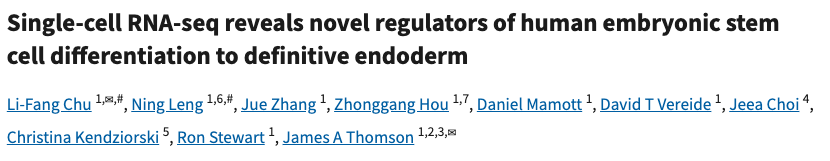

https://pmc.ncbi.nlm.nih.gov/articles/PMC4989499/

In [106]:
# Define the cluster order
cluster_order = list(range(1, 6)) 

# Define the gene for knockout analysis
gene_KO = "T"

# Generated KO Gene Activity data
generated_spins_merged = np.concatenate([simulated_KO_ga[gene_KO][:, :, ii] for ii in range(simulated_KO_ga[gene_KO].shape[2])], axis=1)

# Define two genes of interest for comparison
gene1 = "CXCR4"
gene2 = "T"

def analyze_knockout_gene_activity(ko_gene, gene1, gene2, genes_per_ko, generated_spins, ko_datasets, buffered_polygons, cluster_colors, cluster_order):
    """
    Analyze and compare knockout gene activity between two genes across clusters.

    Returns: tuple: Containing active and inactive cell counts for both genes.
    """
    if ko_gene == gene1:
        idx_gene2 = np.where(genes_per_ko[ko_gene] == gene2)[0][0]
        active_counts_1 = np.zeros(len(cluster_order))
        active_counts_2, inactive_counts_2 = calculate_cluster_counts(generated_spins, idx_gene2, buffered_polygons, cluster_colors, cluster_order, ko_datasets[ko_gene])
        inactive_counts_1 =  active_counts_2+active_counts_2
        
    
    elif ko_gene == gene2:
        idx_gene1 = np.where(genes_per_ko[ko_gene] == gene1)[0][0]
        active_counts_2 = np.zeros(len(cluster_order))
        active_counts_1, inactive_counts_1 = calculate_cluster_counts(generated_spins, idx_gene1, buffered_polygons, cluster_colors, cluster_order, ko_datasets[ko_gene])
        inactive_counts_2 =  active_counts_1+active_counts_1

    else:
        idx_gene1 = np.where(genes_per_ko[ko_gene] == gene1)[0][0]
        idx_gene2 = np.where(genes_per_ko[ko_gene] == gene2)[0][0]
        active_counts_1, inactive_counts_1 = calculate_cluster_counts(generated_spins, idx_gene1, buffered_polygons, cluster_colors, cluster_order, ko_datasets[ko_gene])
        active_counts_2, inactive_counts_2 = calculate_cluster_counts(generated_spins, idx_gene2, buffered_polygons, cluster_colors, cluster_order, ko_datasets[ko_gene])

        # Check for equality in total cell counts between both gene analyses
        if np.sum(active_counts_2) + np.sum(inactive_counts_2) != np.sum(active_counts_1) + np.sum(inactive_counts_1):
            print("ERROR: The number of cells are NOT the same for both genes")

    return (active_counts_1, inactive_counts_1), (active_counts_2, inactive_counts_2)

(active_counts_np1, inactive_counts_np1), (active_counts_np2, inactive_counts_np2) = analyze_knockout_gene_activity(gene_KO, "CXCR4", "T", genes_per_ko, generated_spins_merged, ko_datasets, buffered_polygons, cluster_colors, cluster_order)




In [107]:
def calculate_activity_ratio(counts_active_1, counts_active_2):
    """
    Calculate the activity ratio between two arrays of active cell counts.
    """
    ratio_active_ko = np.zeros(len(counts_active_1))
    
    for index in range(len(counts_active_1)):
        if counts_active_1[index] == 0 and counts_active_2[index] == 0:
            ratio_active_ko[index] = 0
        elif counts_active_2[index] == 0 and counts_active_1[index] > 20:
            ratio_active_ko[index] = counts_active_1[index]  # Previously divided by (counts_active_2[index] + 1) which is avoided now for clarity
        elif counts_active_1[index] == 0:
            ratio_active_ko[index] = 0
        # Otherwise, calculate the ratio normally
        else:
            ratio_active_ko[index] = counts_active_1[index] / counts_active_2[index]

    return ratio_active_ko

ratio_active_ko = calculate_activity_ratio(active_counts_np1, active_counts_np2)

In [109]:
# Define the cluster order
cluster_order = list(range(1, 6)) 

# Define the gene for knockout analysis
# gene_KOs = np.array(["CXCR4", "OTX2", "SOX4", "ZIC2", "SOX17", "KLF8", "POU5F1", "T"])
gene_KOs = np.array(["OTX2", "SOX4", "ZIC2", "SOX17", "KLF8", "POU5F1", "T"])

# Define two genes of interest for comparison
gene1 = "CXCR4"
gene2 = "T"
diff_score =  []
for gene_KO in gene_KOs:
    # Generated KO Gene Activity data
    generated_spins_merged = np.concatenate([simulated_KO_ga[gene_KO][:, :, ii] for ii in range(simulated_KO_ga[gene_KO].shape[2])], axis=1)
    (active_counts_np1, inactive_counts_np1), (active_counts_np2, inactive_counts_np2) = analyze_knockout_gene_activity(gene_KO, "CXCR4", "T", genes_per_ko, generated_spins_merged, ko_datasets, buffered_polygons, cluster_colors, cluster_order)
    ratio_active_ko = calculate_activity_ratio(active_counts_np1, active_counts_np2)
    reference_ratio_active_ko = ratio_active_ko[3] # cluster 4
    diff_score.append(reference_ratio_active_ko/reference_ratio_active_wt)
    
    # if gene_KO == "T":
    print("Plotting CXCR4")
    # Plotting the fraction of active cells for each gene across clusters
    total_cells_ko = (active_counts_np1 + inactive_counts_np1)
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    ax.bar(cluster_order, active_counts_np1 / total_cells_ko, color='darkblue')
    ax.set_title(f"{gene1} - "+ f" {gene_KO} KO")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Fraction of active cells")
    ax.set_xlim(0.5, num_clusters+0.5)
    ax.set_xticks(cluster_order)
    ax.set_ylim(0,1)
    plt.tight_layout()
    # plt.show()
    # fig.savefig(f"/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/active_cells/KO_{gene_KO}_active_CXCR4_cells.svg", format="svg")
    plt.close()
    
    print("Plotting T")
    # Plotting the fraction of active cells for each gene across clusters
    total_cells_ko = (active_counts_np2 + inactive_counts_np2)
    fig, ax = plt.subplots(1, 1, figsize=(3, 3))
    ax.bar(cluster_order, active_counts_np2 / total_cells_ko, color='darkblue')
    ax.set_title(f"{gene2} - "+ f" {gene_KO} KO")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Fraction of active cells")
    ax.set_xlim(0.5, num_clusters+0.5)
    ax.set_xticks(cluster_order)
    ax.set_ylim(0,1)
    plt.tight_layout()
    # plt.show()
    # fig.savefig(f"/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/active_cells/KO_{gene_KO}_active_T_cells.svg", format="svg")
    plt.close()

Plotting CXCR4
Plotting T
Plotting CXCR4
Plotting T
Plotting CXCR4
Plotting T
Plotting CXCR4
Plotting T
Plotting CXCR4
Plotting T
Plotting CXCR4
Plotting T
Plotting CXCR4
Plotting T


/var/folders/2z/hsgwjl3d49109llzgvkyf6jw0000gn/T/ipykernel_27081/245674952.py:41: RuntimeWarning: invalid value encountered in divide
  ax.bar(cluster_order, active_counts_np2 / total_cells_ko, color='darkblue')


In [109]:
# # Define the cluster order
# cluster_order = list(range(1, 6)) 

# # Define the gene for knockout analysis
# gene_KOs = np.array(["CXCR4"])  

# # Define two genes of interest for comparison
# gene1 = "T"
# gene2 = "T"
# diff_score =  []
# for gene_KO in gene_KOs:
#     # Generated KO Gene Activity data
#     generated_spins_merged = np.concatenate([simulated_KO_ga[gene_KO][:, :, ii] for ii in range(simulated_KO_ga[gene_KO].shape[2])], axis=1)
#     (active_counts_np1, inactive_counts_np1), (active_counts_np2, inactive_counts_np2) = analyze_knockout_gene_activity(gene_KO, 
#                                                                                                                         gene1, gene2, 
#                                                                                                                         genes_per_ko, 
#                                                                                                                         generated_spins_merged, 
#                                                                                                                         ko_datasets, 
#                                                                                                                         buffered_polygons, 
#                                                                                                                         cluster_colors, 
#                                                                                                                         cluster_order)
    
#     # Plotting the fraction of active cells for each gene across clusters
#     total_cells_ko = (active_counts_np1 + inactive_counts_np1)
#     fig, ax = plt.subplots(1, 1, figsize=(3, 3))
#     ax.bar(cluster_order, active_counts_np1 / total_cells_ko, color='darkorange')
#     ax.set_title(f"{gene1} - KO of {gene_KOs[0]}")
#     ax.set_xlabel("Cluster")
#     ax.set_ylabel("Fraction of active cells")
#     ax.set_xlim(0.5, num_clusters+0.5)

#     plt.tight_layout()
#     plt.show()

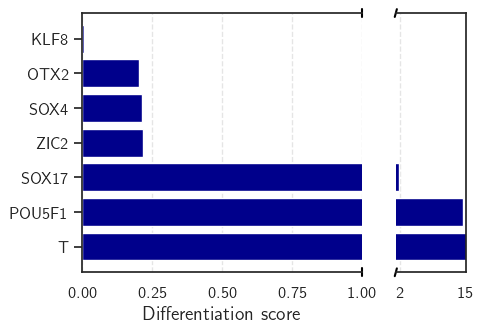

In [110]:
# Sort values in descending order
sorted_indices = np.argsort(diff_score)[::-1]  
gene_KOs_sorted = [gene_KOs[i] for i in sorted_indices]
diff_score_sorted = [diff_score[i] for i in sorted_indices]

positions = np.arange(len(gene_KOs_sorted))  
fig_diff_scores, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(5, 3.5), gridspec_kw={'width_ratios': [4, 1]})

ax1.barh(positions, diff_score_sorted, color='darkblue')
ax1.set_xlim(0, 1)  
ax1.set_xticks(np.linspace(0, 1, 5))  
ax1.set_xticklabels([f"{x:.2f}" for x in np.linspace(0, 1, 5)], fontsize=12)
ax1.set_yticks(positions)
ax1.set_yticklabels(gene_KOs_sorted, fontsize=12)
ax1.set_xlabel('Differentiation score', fontsize=14)
ax1.grid(axis='x', linestyle="--", alpha=0.5)

ax2.barh(positions, diff_score_sorted, color='darkblue')
ax2.set_xlim(1.1, 15)  
ax2.set_xticks([2, 15])  
ax2.set_xticklabels(["2", "15"], fontsize=12)
ax2.grid(axis='x', linestyle="--", alpha=0.5)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.yaxis.tick_left()
ax2.yaxis.set_visible(False) 

# Diagonal space
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='black', clip_on=False, lw=1.5)

ax1.plot([1, 1], [-d, +d], **kwargs)  
ax1.plot([1, 1], [1-d, 1+d], **kwargs)

kwargs = dict(transform=ax2.transAxes, color='black', clip_on=False, lw=1.5)
ax2.plot([-d, +d], [-d, +d], **kwargs)  
ax2.plot([-d, +d], [1-d, 1+d], **kwargs)  
plt.tight_layout()
fig_diff_scores.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/differentiation_scores.svg", format="svg")
plt.show()

## Other Comparisons

In [111]:
def create_subplot_grid(num_genes, plot_width=12, plot_height=8):
    """
    Create a subplot grid for a given number of genes.
    Returns: Tuple containing the figure and axes array:
        fig, axs: Matplotlib figure and axes array.
    """
    cols = int(np.ceil(np.sqrt(num_genes)))
    if cols>3:
        cols = 3
    rows = int(np.ceil(num_genes / cols))
    
    # Create the subplot figure with calculated rows and columns
    fig, axs = plt.subplots(rows, cols, figsize=(plot_width, plot_height))
    
    if num_genes % cols != 0:
        for ax in axs.flat[num_genes:]:
            ax.axis('off')

    if num_genes > 1:
        axs = axs.flatten()

    return fig, axs

In [112]:
def analyze_knockout_gene_activities(ko_gene, genes_list, genes_per_ko, generated_spins, ko_datasets, buffered_polygons, cluster_colors, cluster_order):
    """
    Analyze and compare knockout gene activity across multiple genes within clusters.
    Returns: Dictionary of tuples containing active and inactive cell counts for each gene for each cluster.
    """
    results = {}
    for gene in genes_list:
        idx_gene = np.where(genes_per_ko[ko_gene] == gene)[0][0]
        active_counts, inactive_counts = calculate_cluster_counts(generated_spins, idx_gene, buffered_polygons, cluster_colors, cluster_order, ko_datasets[ko_gene])
        results[gene] = (active_counts, inactive_counts)

    return results

## Fraction of active genes Analysis

In [113]:
# from shapely.geometry import Point, MultiPolygon

# def calculate_points_in_clusters_no_plot(data, buffered_polygons, cluster_ids, priority_order):
#     """
#     Calculate how many and which points in a dataset belong to each cluster or are excluded.
   
#     Parameters:
#     - data: DataFrame containing 'PC1' and 'PC2' coordinates.
#     - buffered_polygons: Dictionary mapping cluster IDs to polygons.
#     - cluster_ids: List of cluster IDs to consider.
#     - priority_order: List defining the priority order of cluster assignment.

#     Returns:
#     - points_count: Dictionary with counts for each cluster and excluded points.
#     """
#     # Initialize counts for each cluster
#     points_count = {cluster_id: 0 for cluster_id in cluster_ids}
#     excluded_count = 0

#     for _, row in data.iterrows():
#         point = Point(row['PC1'], row['PC2'])
#         found_cluster = False

#         for cluster_id in priority_order:
#             if cluster_id in buffered_polygons:
#                 polygon = buffered_polygons[cluster_id]

#                 # Check for MultiPolygon case
#                 if isinstance(polygon, MultiPolygon):
#                     if any(subpolygon.contains(point) for subpolygon in polygon.geoms):
#                         points_count[cluster_id] += 1
#                         found_cluster = True
#                         break
#                 else:
#                     if polygon.contains(point):
#                         points_count[cluster_id] += 1
#                         found_cluster = True
#                         break

#         if not found_cluster:
#             excluded_count += 1

#     # Add excluded points to the count
#     points_count['Excluded'] = excluded_count

#     return points_count

# def calculate_cluster_counts(data, gene_index, buffered_polygons, cluster_ids, cluster_order, principalDf):
#     """ Calculate the number of active and inactive cells for a given gene in each cluster."""
#     active_indices = data[gene_index, :] == 1
#     inactive_indices = data[gene_index, :] == -1

#     # Compute the number of active and inactive cells in each cluster
#     active_principalDf = principalDf[active_indices]
#     inactive_principalDf = principalDf[inactive_indices]

#     active_cluster_counts= calculate_points_in_clusters_no_plot(active_principalDf, buffered_polygons, cluster_ids, cluster_order)
#     inactive_cluster_counts = calculate_points_in_clusters_no_plot(inactive_principalDf, buffered_polygons, cluster_ids, cluster_order)

#     # Reorder the counts based on the cluster order
#     active_counts_np = np.array([active_cluster_counts.get(cluster, 0) for cluster in cluster_order])
#     inactive_counts_np = np.array([inactive_cluster_counts.get(cluster, 0) for cluster in cluster_order])

#     return active_counts_np, inactive_counts_np


In [114]:
# def compute_activity_fractions(grouped_indices, genes_list, genes_relevant, 
#                                simulated_KO_ga, generated_spins, model_n, 
#                                pca_wt_input, buffered_polygons, cluster_ids, 
#                                cluster_order, knockout=True, gene_KO=None):
#     """
#     Compute fraction of active cells per cluster for KO or WT datasets.
    
#     Parameters:
#     - grouped_indices: List of dataset indices to process.
#     - genes_list: List of genes to analyze.
#     - genes_relevant: Array of relevant gene names.
#     - simulated_KO_ga: Dictionary of KO-generated gene activity data.
#     - generated_spins: Array of WT-generated spins.
#     - model_n: Index of the model to use for WT data.
#     - pca_wt_input: PCA transformation object.
#     - buffered_polygons: Spatial clustering polygons.
#     - cluster_order: List defining cluster order.
#     - knockout: Boolean, whether to process KO (True) or WT (False).
#     - gene_KO: Name of the knocked-out gene if processing KO.

#     Returns:
#     - List of dictionaries containing cluster, group, gene, and fraction values.
#     """
#     frac_results = []
    
#     for group_idx, group in enumerate(tqdm(grouped_indices, desc="Processing Groups")):
#         # Concatenate datasets in the group
#         if knockout:
#             if gene_KO is None:
#                 raise ValueError("gene_KO must be provided when processing KO data.")
#             merged_data = np.concatenate([simulated_KO_ga[gene_KO][:, :, i] for i in group], axis=1)
#             index_gene = np.where(genes_relevant == gene_KO)[0][0]
#             merged_data = np.insert(merged_data, index_gene, -1, axis=0)  # Mark KO gene
#         else:
#             merged_data = np.concatenate([generated_spins[model_n, :, :, i] for i in group], axis=1)

#         # Perform PCA transformation
#         transformed_data = pca_wt_input.transform(merged_data.T)
#         principalDf = pd.DataFrame(data=transformed_data, columns=['PC1', 'PC2'])
        
#         # Compute active/inactive fractions for each gene
#         for gene in genes_list:
#             idx_gene = np.where(genes_relevant == gene)[0][0]
#             active_counts, inactive_counts = calculate_cluster_counts(
#                 merged_data, idx_gene, buffered_polygons, cluster_ids, cluster_order, principalDf)
            
#             # total_cells = active_counts + inactive_counts
#             frac_active = active_counts.copy() #np.where(total_cells > 0, active_counts / total_cells, 0)
            
#             # Store results
#             for cluster_id, frac in zip(cluster_order, frac_active):
#                 frac_results.append({
#                     'Cluster': cluster_id,
#                     'Group': group_idx + 1,
#                     'Gene': gene,
#                     'Fraction': frac
#                 })
    
#     return frac_results

In [115]:
# def check_normality(df, groupby_cols, value_col):
#     """Perform normality tests (Shapiro-Wilk and Kolmogorov-Smirnov) for each group."""
#     results = []
    
#     for group, subset in df.groupby(groupby_cols):
#         values = subset[value_col].dropna()
        
#         if len(values) > 3:
#             shapiro_p = shapiro(values)[1] if len(values) < 50 else np.nan
#             ks_p = kstest(values, 'norm', args=(values.mean(), values.std()))[1]
#             mean_val = values.mean()
#             sem_val = values.std(ddof=1) / np.sqrt(len(values))
#             is_normal = (shapiro_p > 0.05 if not np.isnan(shapiro_p) else False) or (ks_p > 0.05)
#             results.append(group + (mean_val, sem_val, shapiro_p, ks_p, is_normal))
    
#     return pd.DataFrame(results, columns=groupby_cols + ["Mean", "SEM", "Shapiro_p", "KS_p", "Is_Normal"])

## PCA of KO GA

### PCA with densities

POU5F1
T
NANOG


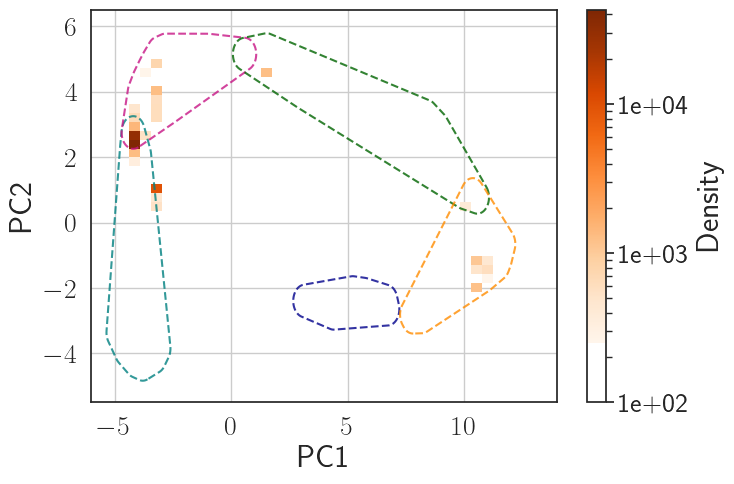

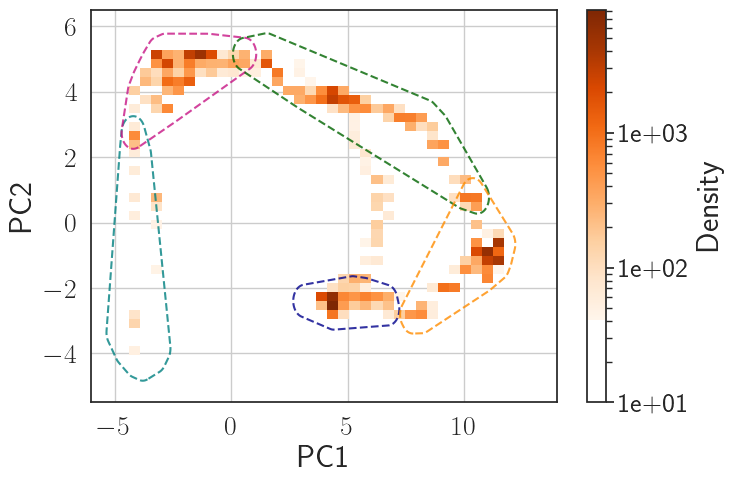

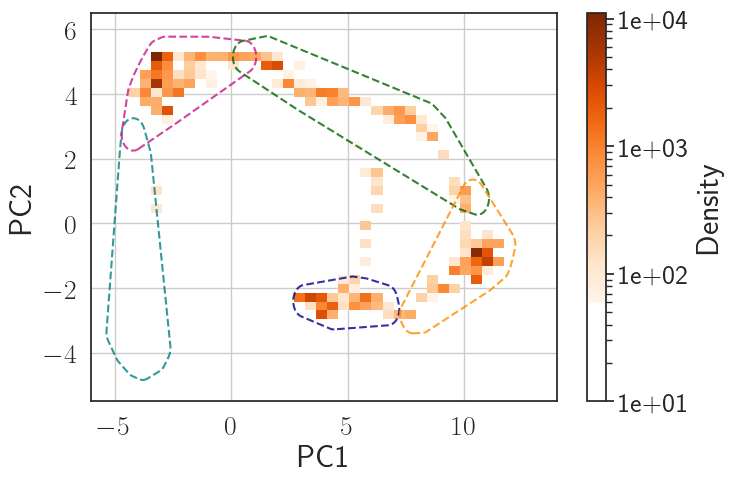

In [113]:
genes_to_keep = ['POU5F1', 'T', "NANOG",]#['T']

sub_dict = {key: ko_datasets[key] for key in genes_to_keep}

for ii in genes_to_keep: 
    print(ii)
    plot_pca_space_with_density(sub_dict[ii], buffered_polygons, cluster_colors, priority_order, 
                            x_bins=x_bins, y_bins=y_bins, threshold=0.005, cmap="Oranges", log_scale_ticks= True)

# cl_funcs.generate_ko_pca_density(sub_dict, principalDf_input, x_bins, y_bins, cmap_personalized, threshold=0.05)


### PCA with clusters

In [114]:
compute_fraction_ko_cl = False
# Calculate and show progress
if compute_fraction_ko_cl:
    results_df = cl_funcs.calculate_ko_cluster_fractions(
        ko_datasets, cluster_polygons, buffered_polygons, cluster_colors, priority_order, buffer_size
    )
    results_df.to_csv(path+"/output_data/ko_output/by_clust/no_scode_genes/cl_frac/clusterig_ko_fractions"+today+".csv")
else:
    # load from output_data/clusterig_ko_fractions.csv
    results_df = pd.read_csv(path + "/output_data/ko_output/by_clust/no_scode_genes/cl_frac/clusterig_ko_fractions"+today+".csv", index_col=0)
    results_df.index.name = None

# Display the resulting DataFrame
results_df.head(3)

,1,2,3,4,5,Excluded
AEBP2,0.044213,0.228764,0.256587,0.260921,0.129845,0.079671
AFF3,0.022398,0.126591,0.097536,0.173324,0.572638,0.007513
ARGFX,0.022661,0.170654,0.093126,0.168792,0.538242,0.006526


# Heatmap for comparison

In [115]:
from shapely.geometry import Point
from joblib import Parallel, delayed

# Function to process a batch for KOs
def process_batch_ko(batch_idx, simulated_KO_ga_per_gene, key_gene, pca_wt_input, buffered_polygons, cluster_colors, priority_order):
    warnings.simplefilter("ignore", category=UserWarning)  # Ignora i warning solo per questa funzione

    start_idx = batch_idx * batch_size
    end_idx = start_idx + batch_size
    
    batch_data = np.concatenate([simulated_KO_ga_per_gene[key_gene][:, :, ii] for ii in range(start_idx, end_idx)], axis=1)
    index_gene = np.where(spins_df_lN_mb_pst.index == key_gene)[0][0]
    batch_data = np.insert(batch_data, index_gene, -1, axis=0)
    
    # Perform PCA
    wt_transformed = pca_wt_input.transform(batch_data.T)
    principalDf_ko_ga = pd.DataFrame(data=wt_transformed, columns=['PC1', 'PC2'])

    # Compute points count for this batch
    points_count, _ = cl_funcs.calculate_points_in_clusters(principalDf_ko_ga, buffered_polygons, cluster_colors, priority_order)
    
    # Convert counts to fractions
    total_points = sum(points_count.values()) 
    if total_points > 0:
        points_count = {k: v / total_points for k, v in points_count.items()}  

    return points_count  


In [116]:
# Define batch size
batch_size = 1

# Initialize dictionaries to store results
cluster_means_dict = {}
cluster_sems_dict = {}

cluster_colors = {
    1: 'darkblue',
    2: 'darkorange',
    3: 'darkgreen',
    4: 'mediumvioletred',
    5: 'teal',
    # 6: 'firebrick',
}

# Iterate over each gene key
# genes_list = ["EOMES", "GATA3", "GATA4", "GATA6", "HAND1", "ID1", "ID2", 
#               "MIXL1", "MSX1", "NANOG", "SOX17", "SOX2", "SOX7", "T", "TFAP2A",
#               "POU5F1", "KLF8", "CXCR4", "HNF4A", "ZIC2", "SOX4", "OTX2"]
genes_list = ["POU5F1", "NANOG", "SOX2", "ZIC2",
              "ID1", "ID2", "TFAP2A", "SOX4", 
               "GATA3", 
               "T",
              "EOMES", "MSX1", 
              "GATA4", "GATA6", "OTX2",
              "HAND1", "SOX7", 
              "MIXL1",
              "KLF8", 
              "SOX17", "CXCR4",
               "HNF4A"]

for key_gene in genes_list: #cluster_means_df_ko.index:
    print("Elaborating gene", key_gene)
    num_batches = simulated_KO_ga[key_gene].shape[2] // batch_size
    
    # Run batches in parallel
    results_ko_gene = Parallel(n_jobs=-1)(
        delayed(process_batch_ko)(batch_idx, simulated_KO_ga, key_gene, pca_wt_input, buffered_polygons, cluster_colors, priority_order)
        for batch_idx in range(num_batches)
    )
    
    # Aggregate results
    cluster_fractions_ok = {cluster_id: [] for cluster_id in cluster_colors.keys()}
    cluster_fractions_ok['Excluded'] = []  # Include unassigned points
    
    for points_fraction in results_ko_gene:
        for cluster_id, fraction in points_fraction.items():
            cluster_fractions_ok[cluster_id].append(fraction)
    
    # Compute mean and SEM for each cluster
    cluster_means_ko, cluster_sems_ko = compute_mean_sem(cluster_fractions_ok)
    
    # Store results
    cluster_means_dict[key_gene] = cluster_means_ko
    cluster_sems_dict[key_gene] = cluster_sems_ko

# Convert to DataFrame
cluster_means_df_ko = pd.DataFrame.from_dict(cluster_means_dict, orient='index')
cluster_sems_df_ko = pd.DataFrame.from_dict(cluster_sems_dict, orient='index')



Elaborating gene POU5F1
Elaborating gene NANOG
Elaborating gene SOX2
Elaborating gene ZIC2
Elaborating gene ID1
Elaborating gene ID2
Elaborating gene TFAP2A
Elaborating gene SOX4
Elaborating gene GATA3
Elaborating gene T
Elaborating gene EOMES
Elaborating gene MSX1
Elaborating gene GATA4
Elaborating gene GATA6
Elaborating gene OTX2
Elaborating gene HAND1
Elaborating gene SOX7
Elaborating gene MIXL1
Elaborating gene KLF8
Elaborating gene SOX17
Elaborating gene CXCR4
Elaborating gene HNF4A


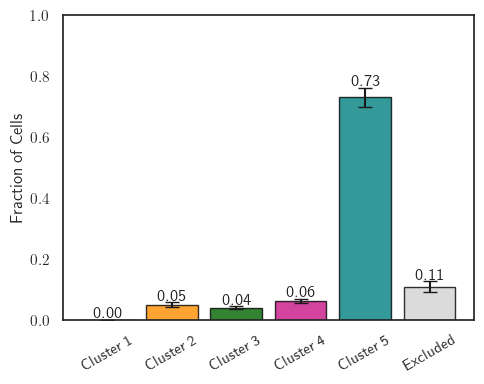

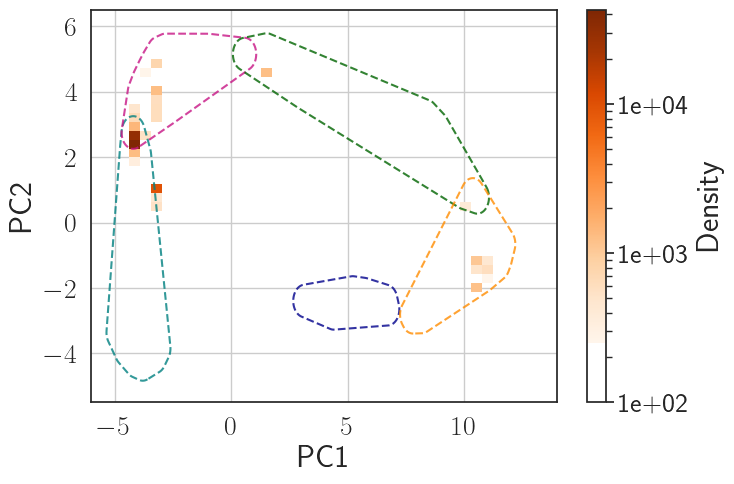

In [118]:
gene = "POU5F1" # POU5F1

fig_hist_generated_ko_pou5f1 = plot_cluster_fractions(cluster_means_df_ko.loc[gene], cluster_sems_df_ko.loc[gene], cluster_colors)
fig_hist_generated_ko_pou5f1.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/histogram_frac_ga_ko_"+gene+".svg", format="svg")


pca_ko = plot_pca_space_with_density(ko_datasets[gene], buffered_polygons, cluster_colors, priority_order, 
                            x_bins=x_bins, y_bins=y_bins, threshold=0.005, cmap="Oranges", log_scale_ticks= True)
pca_ko.savefig("/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig7/pca_ko_"+gene+".svg", format="svg")

In [120]:
genes_list = ["POU5F1", "NANOG", "SOX2", "ZIC2",
              "ID1", "ID2", "TFAP2A", "SOX4", 
               "GATA3", 
               "T",
              "EOMES", "MSX1", 
              "GATA4", "GATA6", "OTX2",
              "HAND1", "SOX7", 
              "MIXL1",
              "KLF8", 
              "SOX17", "CXCR4",
               "HNF4A"]

In [ ]:
selected_clusters = [1, 2, 3, 4, 5, "Excluded"]
cluster_means_df_ko.columns = cluster_means_df_ko.columns.astype(str)

def plot_ko_heatmap(wt_values, ko_means, gene_names, selected_clusters):
    """
    Generate a heatmap where:
    - The first row represents WT ("WT GA").
    - The remaining rows represent KO values, with color indicating (KO - WT).
    """

    # Ensure selected_clusters are sorted as strings
    selected_clusters_sorted = sorted([str(c) for c in selected_clusters])  

    # Ensure WT values are in dictionary format with string keys
    if isinstance(wt_values, list):
        wt_values = dict(zip(selected_clusters_sorted, wt_values))
    else:
        wt_values = {str(k): v for k, v in wt_values.items() if str(k) in selected_clusters_sorted}


    # Create WT DataFrame ensuring the same order of columns
    wt_df = pd.DataFrame([wt_values], index=["WT GA"], columns=selected_clusters_sorted)

    # Filter KO results to only include selected clusters
    ko_df = ko_means[selected_clusters_sorted].loc[gene_names].copy()
    ko_df.index = [f"{g} " for g in gene_names]

    # Compute the difference between KO and WT
    diff_df = ko_df.subtract(wt_df.values[0], axis=1)

    # Combine WT and KO data
    combined_df = diff_df.copy()
    # combined_df = diff_df / max(abs(diff_df.min().min()), abs(diff_df.max().max()))
    
    # Ensure values are scalars before passing to max()
    vmin = -max(abs(combined_df.to_numpy().min()), abs(combined_df.to_numpy().max()))
    vmax = max(abs(combined_df.to_numpy().min()), abs(combined_df.to_numpy().max()))

    # Plot heatmap
    plt.figure(figsize=(6, len(combined_df) * 0.4))
    sns.heatmap(combined_df, cmap="coolwarm", center=0, vmin=vmin, vmax=vmax,
                annot=True, fmt=".2f", linewidths=0.5, cbar_kws={'label': "KO - WT Fraction of cells"})

    plt.xticks(rotation=90, fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel("Clusters", fontsize=14)
    # plt.ylabel("Genes", fontsize=14)
    
    plt.show()


# plot_ko_heatmap(frac_wt_ga_gen, cluster_means_df_ko, genes_list,  selected_clusters)

## Clustering of the KO frac of clust

In [ ]:
results_df = cl_funcs.calculate_ko_cluster_fractions(ko_datasets, 
                                                     cluster_polygons, 
                                                     buffered_polygons, 
                                                     cluster_colors, 
                                                     priority_order, 
                                                     buffer_size)

Processing KOs: 100%|██████████| 98/98 [08:58<00:00,  5.49s/it]


In [126]:
diff_frac_ko_wt = results_df - frac_wt_ga_input
diff_frac_ko_wt

,1,2,3,4,5,Excluded
AEBP2,-0.050287,0.091951,0.156446,0.018326,-0.296107,0.079671
AFF3,-0.072102,-0.010221,-0.002605,-0.069271,0.146685,0.007513
ARGFX,-0.071838,0.033841,-0.007015,-0.073803,0.112290,0.006526
ARID3A,0.038862,-0.014283,0.086610,0.103112,-0.283846,0.069544
BMP2,0.259031,0.148999,0.106309,-0.133963,-0.424598,0.044222
...,...,...,...,...,...,...
ZNF652,-0.084795,0.152393,-0.010165,-0.102520,0.025877,0.019210
ZNF662,-0.071105,-0.023357,-0.030917,0.034640,0.083874,0.006864
ZNF667,-0.040564,0.111641,0.172685,-0.091500,-0.174452,0.022191
ZNF713,-0.068152,-0.003188,0.002078,0.015430,0.046732,0.007099


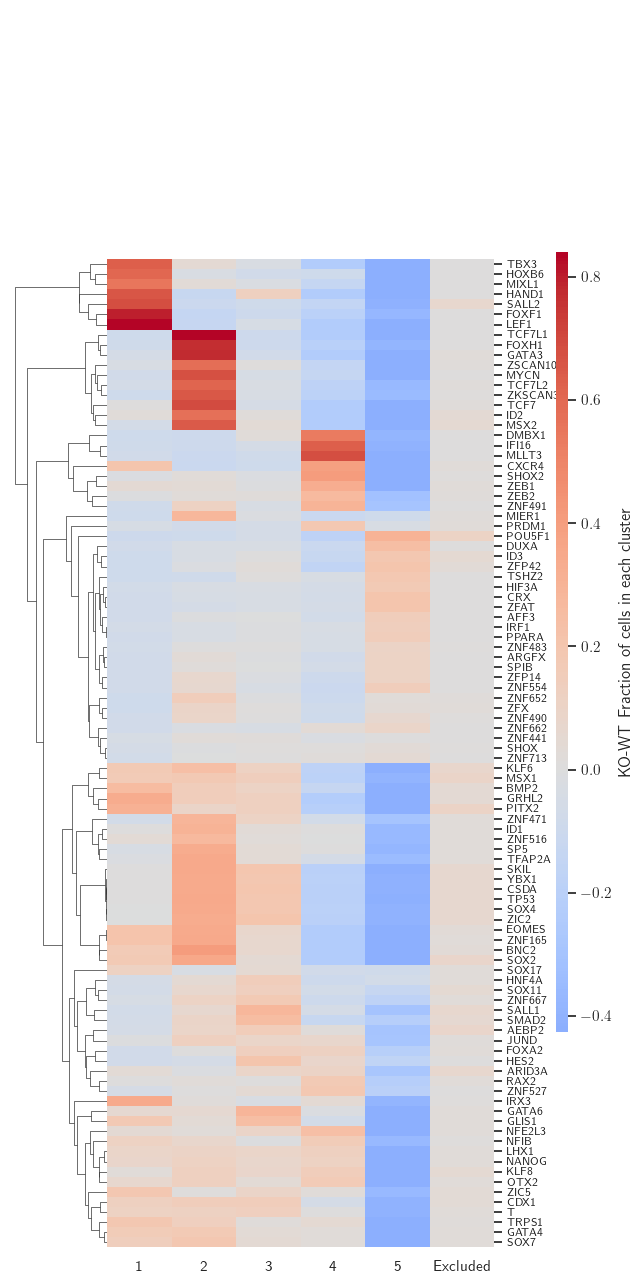

In [127]:
col_linkage_frac_cl = scipy.cluster.hierarchy.linkage(diff_frac_ko_wt, method='ward') 

g_frac_cl = sns.clustermap(diff_frac_ko_wt,
                   col_linkage=col_linkage_frac_cl,
                   cmap="coolwarm",#'YlGnBu',
                   yticklabels=diff_frac_ko_wt.index, 
                #    cbar_pos=None,  
                   cbar_kws={'label': 'KO-WT Fraction of cells in each cluster'},
                   figsize=(6, 13), 
                   center = 0,
                   row_cluster=True, 
                   # decreasing fontsize of yticks
                   cbar_pos=(0.94, 0.2, 0.02, 0.6),
                   col_cluster=False)

g_frac_cl.ax_heatmap.set_yticklabels(
    g_frac_cl.ax_heatmap.get_yticklabels(),
    fontsize=8  # Modifica la fontsize qui
)
# save the figure
plt.show()




/var/folders/2z/hsgwjl3d49109llzgvkyf6jw0000gn/T/ipykernel_19939/3902354001.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cluster_colors = plt.cm.get_cmap('tab20', max_num_clusters)


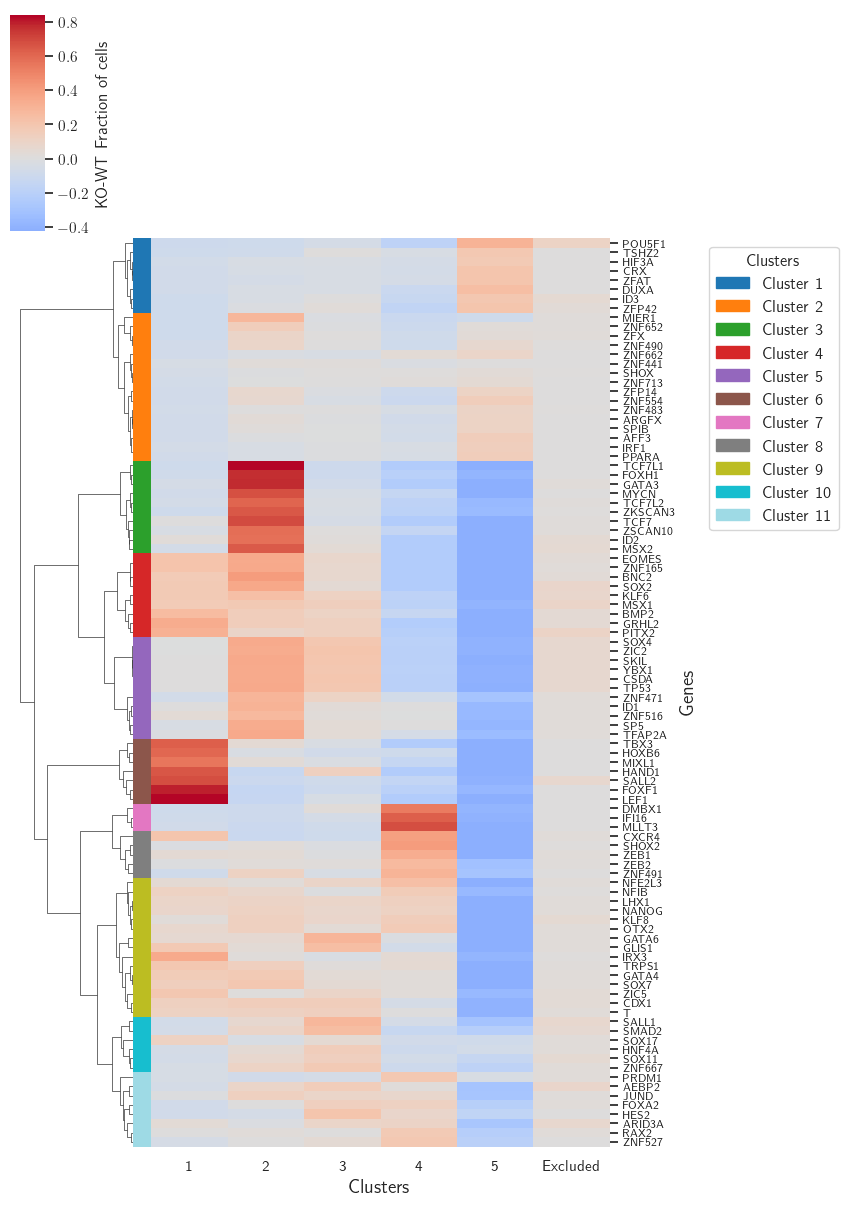

In [128]:
import scipy.cluster.hierarchy as sch
import matplotlib.patches as mpatches


# Compute hierarchical clustering
col_linkage_frac_cl = sch.linkage(diff_frac_ko_wt, method='ward')

# Define number of clusters
max_num_clusters = 11
info_clusters_wt_ga_sim = sch.fcluster(col_linkage_frac_cl, max_num_clusters, criterion='maxclust')

# Create a color mapping for the clusters
cluster_colors = plt.cm.get_cmap('tab20', max_num_clusters)
row_colors = [cluster_colors(cluster - 1) for cluster in info_clusters_wt_ga_sim]

# Plot Clustermap (Heatmap + Dendrogram)
g = sns.clustermap(diff_frac_ko_wt, 
                   row_linkage=col_linkage_frac_cl,
                   cmap="coolwarm",
                   center=0,
                   cbar_kws={'label': 'KO-WT Fraction of cells'},
                   figsize=(7, 12),
                   row_colors=row_colors,  # Assign cluster colors to rows
                   col_cluster=False)  # Disable column clustering

g.ax_heatmap.set_xlabel("Clusters", fontsize=14)
g.ax_heatmap.set_ylabel("Genes", fontsize=14)

# Get the reordered gene names from the clustering
ordered_gene_names = diff_frac_ko_wt.index[g.dendrogram_row.reordered_ind]

# Apply correct y-ticks and labels
g.ax_heatmap.set_yticks(np.arange(len(ordered_gene_names)) + 0.5)
g.ax_heatmap.set_yticklabels(ordered_gene_names, fontsize=8)


# Create a mapping of cluster labels to colors
unique_clusters = np.unique(info_clusters_wt_ga_sim)
legend_patches = [mpatches.Patch(color=cluster_colors(cluster - 1), label=f"Cluster {cluster}") 
                  for cluster in unique_clusters]

# Add the legend to the figure
g.ax_heatmap.legend(handles=legend_patches, title="Clusters", loc="upper left", bbox_to_anchor=(1.2, 1), fontsize=12)
plt.savefig(path + "/output_data/ko_output/by_clust/no_scode_genes/cl_frac/KO_WT_diff_frac_clustering.svg", format="svg", bbox_inches='tight')


plt.show()

In [141]:
import umap
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from adjustText import adjust_text

def plot_dimensionality_reduction(results_df, frac_wt_ga_gen, frac_wt_ga_input, info_clusters_wt_ga_sim, umap_plot=True, genes_to_label=None):
    results_df.loc['WT GEN'] = np.array(frac_wt_ga_gen)
    results_df.loc['WT INPUT'] = np.array(frac_wt_ga_input)

    data = results_df.values

    data_ko = data[:-2]
    data_wt = data[-2:]

    if umap_plot:
        reducer = umap.UMAP(n_neighbors=5, min_dist=0.05, random_state=42)
        result_ko = reducer.fit_transform(data_ko)
        result_wt = reducer.transform(data_wt)
        result = np.vstack([result_ko, result_wt])
    else:
        reducer = PCA(n_components=2)
        result_ko = reducer.fit_transform(data_ko)
        result_wt = reducer.transform(data_wt)
        result = np.vstack([result_ko, result_wt])

    unique_clusters = np.unique(info_clusters_wt_ga_sim)
    colormap = cm.get_cmap('tab20', len(unique_clusters))
    cluster_colors = {cluster: colormap(i) for i, cluster in enumerate(unique_clusters)}

    gene_colors = [cluster_colors[cluster] for cluster in info_clusters_wt_ga_sim]


    wt_color_gen = 'tomato'
    wt_color_input = 'forestgreen'

    plt.figure(figsize=(6,4))

    texts = []  # Store text objects for adjustText

    for i, ko in enumerate(results_df.index):
        if ko == 'WT GEN':
            plt.scatter(result[i, 0], result[i, 1], c=[wt_color_gen], edgecolor=wt_color_gen, s=120,
                        marker='*', label='WT GEN', linewidth=1.5)
        elif ko == 'WT INPUT':
            plt.scatter(result[i, 0], result[i, 1], c=[wt_color_input], edgecolor=wt_color_input, s=120,
                        marker='*', label='WT INPUT', linewidth=1.5)
        else:
            plt.scatter(result[i, 0], result[i, 1], c=[gene_colors[i]], edgecolor='k', s=40, alpha=0.9)
            if genes_to_label and ko in genes_to_label:
                text = plt.text(result[i, 0], result[i, 1], ko, fontsize=9, ha='center', va='center', color='black')
                texts.append(text)

    adjust_text(texts, 
            expand=(2, 2.5),  
            force_text=(0.6, 0.9), 
            force_points=(0.7, 1.0),  
            arrowprops=dict(arrowstyle="-", color='grey', lw=1.2))
    for text in texts:
        text.set_fontsize(10)  # Imposta un font più grande
        text.set_fontweight("bold")

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=cluster_colors[cluster], markersize=10, label=f"{cluster}")
        for cluster in unique_clusters
    ] + [
        Line2D([0], [0], marker='*', color='w', markerfacecolor=wt_color_gen, markersize=12, label='WT GEN'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor=wt_color_input, markersize=12, label='WT INPUT')
    ]

    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Clusters", frameon=False)
    plt.xlabel("UMAP 1" if umap_plot else "PC1")
    plt.ylabel("UMAP 2" if umap_plot else "PC2")
    plt.tight_layout()
    plt.xlim(-.6, .7)
    plt.ylim(-.6, .8)
    plt.savefig('/Users/cleliacorridori/Dropbox_2021 Dropbox/Jorah Mormont/Clelia/IGNITE Paper Material/Figs_Human/Fig8/KO_WT_diff_frac_clustering_UMAP.svg', format="svg", bbox_inches='tight')
    # plt.show()


/var/folders/2z/hsgwjl3d49109llzgvkyf6jw0000gn/T/ipykernel_19939/2158254915.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = cm.get_cmap('tab20', len(unique_clusters))


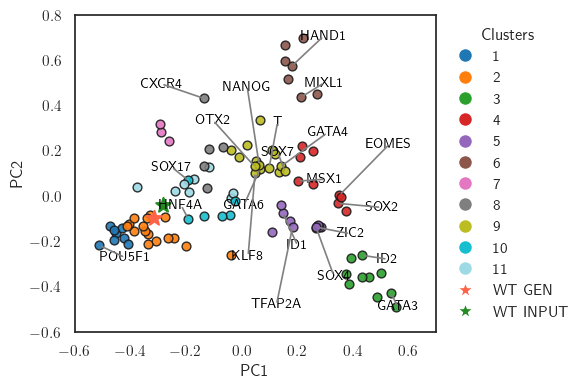

In [144]:
# rename the columns as '1', '2', '3', '4', '5', '6', 'Excl'
results_df.columns = ['1', '2', '3', '4', '5',  'Excluded']
diff_frac_ko_wt.columns = ['1', '2', '3', '4', '5',  'Excluded']
results_df.columns 
plot_dimensionality_reduction(results_df, list(cluster_means.values()), frac_wt_ga_input, info_clusters_wt_ga_sim, umap_plot=False, genes_to_label=genes_list)



/var/folders/2z/hsgwjl3d49109llzgvkyf6jw0000gn/T/ipykernel_5343/3010730652.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


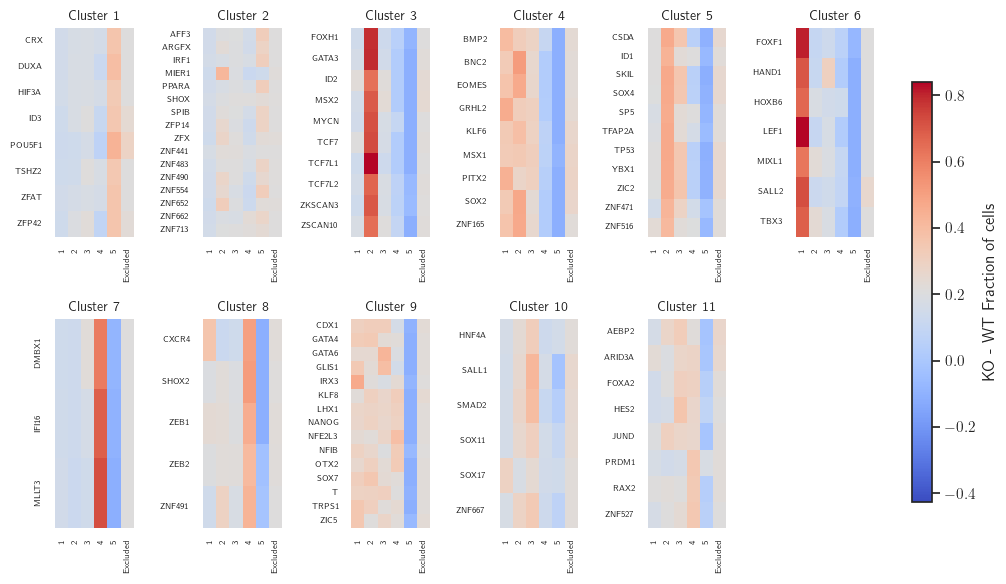

In [143]:
# Find the global minimum and maximum values for all heatmaps
vmin = diff_frac_ko_wt.min().min()  # Minimum value
vmax = diff_frac_ko_wt.max().max()  # Maximum value

# Figure parameters
n_rows = 2
n_cols = 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))
axes = axes.flatten()  # Flatten axes to access them as a single array

# Loop through clusters and create subplots
for idx, cl in enumerate(np.unique(info_clusters_wt_ga_sim)):
    cl_sel = diff_frac_ko_wt.index[info_clusters_wt_ga_sim == cl]
    ax = axes[idx]
    
    # Plot heatmap for the selected cluster
    sns.heatmap(diff_frac_ko_wt.loc[cl_sel, :], 
                cmap='coolwarm', 
                annot=False,
                fmt=".2f", 
                cbar=False,  # Disable individual colorbars
                center=0,
                vmin=vmin, vmax=vmax,  # Use the same color limits for all
                ax=ax)
    
    ax.set_title(f'Cluster {cl}', fontsize=10)  # Set title for each cluster
    ax.set_xlabel("")  # Remove x-axis label
    ax.set_ylabel("")  # Remove y-axis label
    
    # Force all y-ticks to show
    ax.set_yticks(np.arange(0.5,len(cl_sel)+0.5))  # Set tick positions
    ax.set_yticklabels(cl_sel, fontsize=6)  # Set tick labels with reduced font size
    
    # Adjust font size for x-axis ticks
    ax.tick_params(axis='x', labelsize=6)

# Remove unused axes
for i in range(len(np.unique(info_clusters_wt_ga_sim)), len(axes)):
    fig.delaxes(axes[i])

# Add a shared colorbar for all heatmaps
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=vmin, vmax=vmax))
fig.colorbar(sm, cax=cbar_ax, label='KO - WT Fraction of cells')

# Adjust layout to leave space for the colorbar
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()